Last updated: November 19, 2025

I adapted my LA Traffic Collisions & Vision Zero project to do this quick analysis to understand what type of collisions occur on LA highways. [Waymo vehicles are now allowed on LA highways](https://www.ocregister.com/2025/11/13/driverless-waymo-cars-now-venturing-onto-la-freeways/), so I want to investigate what type of accidents occur on the highways and whether it should be a cause for concern.



[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/iris-lew/projects/blob/main/project_001_LATrafficCollisions/LA_Traffic_Collisions_Freeways.ipynb)


# LA Traffic Collisions EDA

On November 19, 2025, I downloaded the data from [LA City's public datasets](https://data.lacity.org/Public-Safety/Traffic-Collision-Data-from-2010-to-Present/d5tf-ez2w). This data contains traffic collisions from 2010 to March 14, 2025.

## Setup

I set up the necessary libraries to import the data, do the analysis, and create plots.

In [1]:
### delete when done
import os
from google.colab import drive
drive.mount('/content/gdrive', force_remount=True)
%cd /content/gdrive/MyDrive/data

Mounted at /content/gdrive
/content/gdrive/MyDrive/data


In [2]:
# Import modules
from copy import deepcopy
from matplotlib import ticker

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import datetime

import folium
from IPython.display import HTML
from folium.plugins import HeatMap

pd.set_option('display.max_columns', None)

from pandas.tseries.holiday import USFederalHolidayCalendar as calendar

import geopandas as gpd
from shapely.geometry import Point

In [3]:
filename = r'Traffic_Collision_Data_from_2010_to_Present_20251119.csv'
dat = pd.read_csv(filename)

dat.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 621677 entries, 0 to 621676
Data columns (total 18 columns):
 #   Column                  Non-Null Count   Dtype  
---  ------                  --------------   -----  
 0   DR Number               621677 non-null  int64  
 1   Date Reported           621677 non-null  object 
 2   Date Occurred           621677 non-null  object 
 3   Time Occurred           621677 non-null  int64  
 4   Area ID                 621677 non-null  int64  
 5   Area Name               621677 non-null  object 
 6   Reporting District      621677 non-null  int64  
 7   Crime Code              621677 non-null  int64  
 8   Crime Code Description  621677 non-null  object 
 9   MO Codes                534353 non-null  object 
 10  Victim Age              533483 non-null  float64
 11  Victim Sex              610980 non-null  object 
 12  Victim Descent          610029 non-null  object 
 13  Premise Code            620718 non-null  float64
 14  Premise Description 

In [4]:
dat.head()

,DR Number,Date Reported,Date Occurred,Time Occurred,Area ID,Area Name,Reporting District,Crime Code,Crime Code Description,MO Codes,Victim Age,Victim Sex,Victim Descent,Premise Code,Premise Description,Address,Cross Street,Location
0,212013850,09/03/2021,09/02/2021,2335,20,Olympic,2021,997,TRAFFIC COLLISION,3004 3027 3034 4027 3036 3101 3401 3701,25.0,F,W,101.0,STREET,WILTON PL,6TH ST,"(34.063, -118.3141)"
1,221417787,10/17/2022,10/17/2022,1620,14,Pacific,1406,997,TRAFFIC COLLISION,4027 3011 3028 3034 3037 3101 3401 3701,21.0,NaN,NaN,101.0,STREET,NATIONAL BL,MOTOR AV,"(34.029, -118.4113)"
2,221418141,10/26/2022,10/26/2022,1135,14,Pacific,1434,997,TRAFFIC COLLISION,4027 3011 3025 3034 3037 3101 3401 3701,21.0,NaN,NaN,101.0,STREET,PALMS BL,ROSEWOOD AV,"(34.0052, -118.4478)"
3,222017859,12/01/2022,12/01/2022,230,20,Olympic,2044,997,TRAFFIC COLLISION,3003 0913 3026 3035 3037 3101 3401 3701 4020,33.0,M,H,101.0,STREET,IROLO ST,SAN MARINO ST,"(34.0545, -118.3009)"
4,190319651,08/24/2019,08/24/2019,450,3,Southwest,356,997,TRAFFIC COLLISION,3036 3004 3026 3101 4003,22.0,M,H,101.0,STREET,JEFFERSON BL,NORMANDIE AV,"(34.0255, -118.3002)"


Renaming the columns with snake casing and lower case.

In [5]:
dat.columns = dat.columns.str.replace(" ","_").str.lower()
dat.head()

,dr_number,date_reported,date_occurred,time_occurred,area_id,area_name,reporting_district,crime_code,crime_code_description,mo_codes,victim_age,victim_sex,victim_descent,premise_code,premise_description,address,cross_street,location
0,212013850,09/03/2021,09/02/2021,2335,20,Olympic,2021,997,TRAFFIC COLLISION,3004 3027 3034 4027 3036 3101 3401 3701,25.0,F,W,101.0,STREET,WILTON PL,6TH ST,"(34.063, -118.3141)"
1,221417787,10/17/2022,10/17/2022,1620,14,Pacific,1406,997,TRAFFIC COLLISION,4027 3011 3028 3034 3037 3101 3401 3701,21.0,NaN,NaN,101.0,STREET,NATIONAL BL,MOTOR AV,"(34.029, -118.4113)"
2,221418141,10/26/2022,10/26/2022,1135,14,Pacific,1434,997,TRAFFIC COLLISION,4027 3011 3025 3034 3037 3101 3401 3701,21.0,NaN,NaN,101.0,STREET,PALMS BL,ROSEWOOD AV,"(34.0052, -118.4478)"
3,222017859,12/01/2022,12/01/2022,230,20,Olympic,2044,997,TRAFFIC COLLISION,3003 0913 3026 3035 3037 3101 3401 3701 4020,33.0,M,H,101.0,STREET,IROLO ST,SAN MARINO ST,"(34.0545, -118.3009)"
4,190319651,08/24/2019,08/24/2019,450,3,Southwest,356,997,TRAFFIC COLLISION,3036 3004 3026 3101 4003,22.0,M,H,101.0,STREET,JEFFERSON BL,NORMANDIE AV,"(34.0255, -118.3002)"


In [6]:
dat.shape

(621677, 18)

The MO Codes are 4 digit numbers, and their corresponding defintions can be found in a PDF at the same link to download the [dataset](https://data.lacity.org/Public-Safety/Traffic-Collision-Data-from-2010-to-Present/d5tf-ez2w). This PDF was converted into a UTF-8 csv file through an external software. Once it was in UTF-8, I read it in using pandas `read_csv` function like above.

I replaced the column names to be more understandable and zero-filled in the code column because the codes in the traffic collision dataset were consistently of length 4.

In [7]:
mo_codes_dict = pd.read_csv("MO_CODES_utf8.csv", header=None)
mo_codes_dict.drop(2, axis=1, inplace=True)
mo_codes_dict.columns = ["mo_code", "code_def"]

#zero fill the mo_codes so it will be a better join with the rest of the dataset.
mo_codes_dict.mo_code = mo_codes_dict.mo_code.astype(str).str.zfill(4)
mo_codes_dict.head()

,mo_code,code_def
0,0100,Suspect Impersonate
1,0101,Aid victim
2,0102,Blind
3,0103,Crippled
4,0104,Customer


## Column Exploration
In data exploration, the next step is to look at each of the individual columns. I used the data dictionary also provided in the link where I downloaded the data from. There were a few topics I could look at together: date/time, location, codes, and victim information.

* Division of Records Number
    * dr_number
* Date/Time:
    * date_reported
    * date_occurred
    * time_occurred
* Location:
    * area_id
    * area_name
    * reporting_district
    * premise_code
    * premise_description
    * address
    * cross_street
    * location
* Code:
    * crime_code
    * crime_code_description
    * mo_codes
* Victim Information
    * victim_age
    * victim_sex
    * victim_descent

### Division of Records number

According to LA's dataset website, the `dr_number` is "Division of Records Number: Official file number made up of a 2 digit year, area ID, and 5 digits." Thus, I expect this to be unique and of a uniform length.

In [8]:
dat.dr_number.astype(str).value_counts().sort_values(ascending=False) #unique

,count
dr_number,
190413937,1
250704195,1
212013850,1
221417787,1
221418141,1
...,...
250704185,1
252004220,1
251004209,1


In [9]:
dat.dr_number.astype(str).map(len).value_counts()

,count
dr_number,
9,621677


Since this is a unique number, I will use `dr_number` **as the index and primary key.**

The definition provided by the codebook indicates that `dr_number` has some relationship with dates and the `area_id` so I decided to cross-check the column with `date_occurred`, `date_reported`, and`area_id`. I find that there are some mismatches, but there wasn't anything systematic at first glance, so it is likely a typo.

In [10]:
print(sum(dat["dr_number"].astype("str").str[:2]!=dat["date_occurred"].astype("str").str[-2:]))
print(sum(dat["dr_number"].astype("str").str[:2]!=dat["date_reported"].astype("str").str[-2:]))
dat[dat["dr_number"].astype("str").str[:2]!=dat["date_reported"].astype("str").str[-2:]].head(5)

4558
1132


,dr_number,date_reported,date_occurred,time_occurred,area_id,area_name,reporting_district,crime_code,crime_code_description,mo_codes,victim_age,victim_sex,victim_descent,premise_code,premise_description,address,cross_street,location
7645,191613917,09/12/2018,09/12/2018,1651,16,Foothill,1651,997,TRAFFIC COLLISION,3004 3028 3030 3037 3101 3401 3701 4016,37.0,F,H,101.0,STREET,GOLDEN STATE,OSBORNE ST,"(34.2455, -118.4177)"
13548,180418940,01/07/2019,12/31/2018,1300,4,Hollenbeck,403,997,TRAFFIC COLLISION,3101 3401 3701 3004 3025 3029,34.0,M,F,101.0,STREET,GRIFFIN,MONTECITO,"(34.0953, -118.2019)"
15022,190814307,08/17/2018,08/17/2018,1135,8,West LA,827,997,TRAFFIC COLLISION,3004 3028 3030 3035 3036 3101 3401 3701 4008,28.0,M,W,101.0,STREET,BEVERLY CT,SUNSET BL,"(34.0638, -118.4703)"
19061,200405346,10/21/2019,10/21/2019,1910,4,Hollenbeck,437,997,TRAFFIC COLLISION,0605 3101 3401 3701 3009 3026 3036,53.0,M,W,101.0,STREET,2500 N SOTO ST,NaN,"(34.0748, -118.194)"
19403,190804496,10/15/2018,10/15/2018,1345,8,West LA,853,997,TRAFFIC COLLISION,3004 3026 3029 3035 3036 3104 3401 3701 4008,NaN,NaN,NaN,101.0,STREET,NATIONAL BL,OVERLAND,"(34.0445, -118.4491)"


In [11]:
dat[dat["dr_number"].astype("str").str[:2]!=dat["date_reported"].astype("str").str[-2:]].tail(5)

,dr_number,date_reported,date_occurred,time_occurred,area_id,area_name,reporting_district,crime_code,crime_code_description,mo_codes,victim_age,victim_sex,victim_descent,premise_code,premise_description,address,cross_street,location
619648,252004035,12/31/2024,12/31/2024,2220,20,Olympic,2049,997,TRAFFIC COLLISION,0605,22.0,M,H,101.0,STREET,8TH ST,MAGNOLIA AV,"(34.0578, -118.2869)"
620134,240800813,02/11/2025,12/04/2024,1715,8,West LA,853,997,TRAFFIC COLLISION,4008 3004 3028 3036 3034 3101 3401 3701,50.0,M,O,101.0,STREET,SANTA MONICA BL,SAWTELLE BL,"(34.0465, -118.4484)"
620634,241010996,02/12/2025,09/13/2024,1,10,West Valley,1008,997,TRAFFIC COLLISION,3004 3028 3030 3101 4010,42.0,M,A,101.0,STREET,WOODLEY AV,RAYMER ST,"(34.2177, -118.4837)"
621442,251104136,11/26/2024,11/26/2024,1137,11,Northeast,1162,997,TRAFFIC COLLISION,0605 4024,34.0,M,W,101.0,STREET,1300 N VERMONT AV,NaN,"(34.0956, -118.2918)"
621642,251304178,12/02/2024,12/02/2024,1045,13,Newton,1385,997,TRAFFIC COLLISION,0605 4024,44.0,F,H,101.0,STREET,1000 E 59TH ST,NaN,"(33.9872, -118.258)"


In [12]:
print(sum(dat["dr_number"].astype("str").str[2:4].astype(int)!=dat["area_id"]))
dat[dat["dr_number"].astype("str").str[2:4].astype(int)!=dat["area_id"]].head(5)

303


,dr_number,date_reported,date_occurred,time_occurred,area_id,area_name,reporting_district,crime_code,crime_code_description,mo_codes,victim_age,victim_sex,victim_descent,premise_code,premise_description,address,cross_street,location
1491,220905098,02/24/2022,01/19/2022,1015,15,N Hollywood,1585,997,TRAFFIC COLLISION,3028 3037 3101 4026 3004 3030,99.0,X,X,101.0,STREET,VINELAND AV,VENTURA BL,"(34.141, -118.3703)"
1962,191611425,07/15/2019,07/14/2019,2225,9,Van Nuys,937,997,TRAFFIC COLLISION,3029 3004 3037 3026 3101 3401 3701 4009,NaN,M,X,101.0,STREET,SYLVAN ST,WOODMAN AV,"(34.1849, -118.4312)"
2846,199928602,08/07/2019,08/07/2019,1505,18,Southeast,1849,997,TRAFFIC COLLISION,0605,60.0,M,H,101.0,STREET,MONA,114TH ST,"(33.9312, -118.2308)"
3168,191318054,09/06/2019,09/06/2019,226,11,Northeast,1113,997,TRAFFIC COLLISION,0330 0906 1402 1805 1816,18.0,M,H,101.0,STREET,2300 FAIR PARK AV,NaN,"(34.1366, -118.2173)"
3398,191916198,09/08/2019,09/06/2019,1840,9,Van Nuys,955,997,TRAFFIC COLLISION,3036 3004 3602 3026 3101 3401 3701 4019,78.0,M,W,101.0,STREET,VAN NUYS BL,MAGNOLIA BL,"(34.1649, -118.4486)"


In [13]:
dat[dat["dr_number"].astype("str").str[2:4].astype(int)!=dat["area_id"]].tail(5)

,dr_number,date_reported,date_occurred,time_occurred,area_id,area_name,reporting_district,crime_code,crime_code_description,mo_codes,victim_age,victim_sex,victim_descent,premise_code,premise_description,address,cross_street,location
615152,241216724,11/02/2024,10/26/2024,2000,18,Southeast,1842,997,TRAFFIC COLLISION,4012 3101 3004 3026,27.0,M,H,101.0,STREET,IMPERIAL HY,MAIN ST,"(33.931, -118.2739)"
615746,241608925,06/20/2024,06/17/2024,450,15,N Hollywood,1522,997,TRAFFIC COLLISION,3009 3024 3037 3101 4016,41.0,M,O,101.0,STREET,VICTORY BL,COLDWATER CANYON AV,"(34.1867, -118.4138)"
617054,241314426,11/02/2024,10/27/2024,1630,1,Central,195,997,TRAFFIC COLLISION,3401 3701 0605 3004 3028 3030 3033 3037 3101 4024,41.0,M,H,101.0,STREET,WASHINGTON AV,MAIN ST,"(34.0316, -118.2656)"
617662,250604103,01/27/2025,01/27/2025,1850,11,Northeast,1151,997,TRAFFIC COLLISION,3003 3025 3029 3033 3035 3036 4027,37.0,M,H,101.0,STREET,SUNSET BL,NORMANDIE AV,"(34.0981, -118.3005)"
618141,241217130,11/15/2024,11/15/2024,1211,3,Southwest,327,997,TRAFFIC COLLISION,3004 3024 4025,20.0,M,H,101.0,STREET,HOOVER ST,28TH ST,"(34.0287, -118.284)"


### Date/Time

I needed to check that the `date_reported`, `date_occurred`, and `time_occurred` columns are valid before converting them into datetime objects. I also need to validate if there are any "catch-alls" values (e.g., if there is an unknown date, it would be coded as January 1, 1900).

In [14]:
date_cols = ["date_reported","date_occurred"]
[dat[i].str[0:2].value_counts().sort_index() for i in date_cols] # Month
[dat[i].str[3:5].value_counts().sort_index() for i in date_cols] # Date
[dat[i].str[-4:].value_counts().sort_index() for i in date_cols] # Year

[date_reported
 2010    44807
 2011    45308
 2012    45374
 2013    45067
 2014    46932
 2015    52383
 2016    56531
 2017    57727
 2018    57149
 2019    56750
 2020    42355
 2021    18922
 2022    16355
 2023    16498
 2024    16825
 2025     2694
 Name: count, dtype: int64,
 date_occurred
 2010    45098
 2011    45280
 2012    45409
 2013    45040
 2014    46957
 2015    52488
 2016    56532
 2017    57727
 2018    57159
 2019    56628
 2020    42385
 2021    18796
 2022    16417
 2023    16461
 2024    16720
 2025     2580
 Name: count, dtype: int64]

In [15]:
dat["date_reported"].value_counts().sort_index()

,count
date_reported,
01/01/2010,86
01/01/2011,125
01/01/2012,100
01/01/2013,121
01/01/2014,107
...,...
12/31/2020,104
12/31/2021,40
12/31/2022,54


In [16]:
dat["date_occurred"].value_counts().sort_index()

,count
date_occurred,
01/01/2010,122
01/01/2011,123
01/01/2012,101
01/01/2013,117
01/01/2014,112
...,...
12/31/2020,93
12/31/2021,40
12/31/2022,66


When examining time, I see that it looks like it is in military time (as is stated in the data dictionary) and **made an assumption that the leading 0's were dropped when it was converted to CSV.** I added in the leading 0's.

In [17]:
dat["time_occurred"].value_counts()

,count
time_occurred,
1800,8304
1700,7888
1600,7767
1500,7617
1900,7172
...,...
434,3
449,3
603,3


In [18]:
dat["time_occurred"].astype(str).map(len).value_counts()

,count
time_occurred,
4,454180
3,150901
2,11722
1,4874


In [19]:
dat["time_occurred"] = dat["time_occurred"].astype(str).apply(lambda x: '0'*(4-len(str(x)))+str(x))
dat["time_occurred"]

,time_occurred
0,2335
1,1620
2,1135
3,0230
4,0450
...,...
621672,0945
621673,0810
621674,0910
621675,1510


In [20]:
dat["time_occurred"].str[0:2].value_counts().sort_index()

,count
time_occurred,
00,16596
01,15222
02,15494
03,10108
04,7475
05,8540
06,13231
07,25880
08,29230


In [21]:
dat["time_occurred"].str[-2:].value_counts().sort_index()

,count
time_occurred,
00,123121
01,3222
02,564
03,540
04,504
05,25347
06,494
07,647
08,764


In [22]:
dat["time_occurred"] = dat["time_occurred"].str[0:2]+":"+dat["time_occurred"].str[-2:]
dat["time_occurred"]

,time_occurred
0,23:35
1,16:20
2,11:35
3,02:30
4,04:50
...,...
621672,09:45
621673,08:10
621674,09:10
621675,15:10


I notice that there is a spike in the `time_occurred` whenever the minutes are a multiple of 5. This is likely because people are are used to rounding to the nearest 5 minutes and thus valid.

It looks like there aren't any invalid dates or times and thus I can convert them into datetime objects.

In [23]:
dat["dttm_occurred"] = pd.to_datetime(dat["date_occurred"]+" "+dat["time_occurred"],
                                      format = "%m/%d/%Y %H:%M",
                                      exact = True)
dat["dttm_occurred"]

,dttm_occurred
0,2021-09-02 23:35:00
1,2022-10-17 16:20:00
2,2022-10-26 11:35:00
3,2022-12-01 02:30:00
4,2019-08-24 04:50:00
...,...
621672,2025-03-02 09:45:00
621673,2025-03-06 08:10:00
621674,2025-02-24 09:10:00
621675,2025-03-07 15:10:00


In [24]:
dat["dttm_occurred"].describe()

,dttm_occurred
count,621677
mean,2016-07-11 19:33:50.762341632
min,2010-01-01 00:05:00
25%,2013-06-11 07:25:00
50%,2016-07-21 10:30:00
75%,2019-04-05 08:50:00
max,2025-03-08 11:10:00


In [25]:
dat["date_reported_dt"] = pd.to_datetime(dat["date_reported"], format = "%m/%d/%Y")
dat["date_reported_dt"]

,date_reported_dt
0,2021-09-03
1,2022-10-17
2,2022-10-26
3,2022-12-01
4,2019-08-24
...,...
621672,2025-03-02
621673,2025-03-06
621674,2025-02-24
621675,2025-03-07


I also wanted to check if there is a difference in `date_occurred` and `date_reported`. I expect most people to report an traffic collision relatively quickly, especially if there is a victim involved. **I decided that if at least one of the three victims columns is filled out, the traffic collision would have considered to have a victim. I will also assume that there is only one victim per traffic collision due to the column restrictions even though it is possible that there are multiple.**

In [26]:
dat["victim"] = ((dat["victim_age"].notna())|(dat["victim_sex"].notna())|(dat["victim_descent"].notna()))
dat["victim"].value_counts()

,count
victim,
True,615192
False,6485


In [27]:
dat["reported_occurred_diff"] = dat["date_reported_dt"].dt.date-dat["dttm_occurred"].dt.date
dat["reported_occurred_diff"].describe()

/tmp/ipython-input-2917418209.py:2: FutureWarning: The behavior of value_counts with object-dtype is deprecated. In a future version, this will *not* perform dtype inference on the resulting index. To retain the old behavior, use `result.index = result.index.infer_objects()`
  dat["reported_occurred_diff"].describe()


,reported_occurred_diff
count,621677
unique,492
top,0 days 00:00:00
freq,435840


In [28]:
# (dat["reported_occurred_diff"].astype("int64")/86400000000000).describe()
dat["reported_occurred_diff_int"] = dat["reported_occurred_diff"].apply(lambda x:x.days)
dat["reported_occurred_diff_int"].describe()

,reported_occurred_diff_int
count,621677.000000
mean,2.651428
std,40.278500
min,0.000000
25%,0.000000
50%,0.000000
75%,1.000000
max,4019.000000


In [29]:
dat["reported_occurred_diff_int"] = dat["reported_occurred_diff"].apply(lambda x:x.days)
dat["reported_occurred_diff_int"].describe()

,reported_occurred_diff_int
count,621677.000000
mean,2.651428
std,40.278500
min,0.000000
25%,0.000000
50%,0.000000
75%,1.000000
max,4019.000000


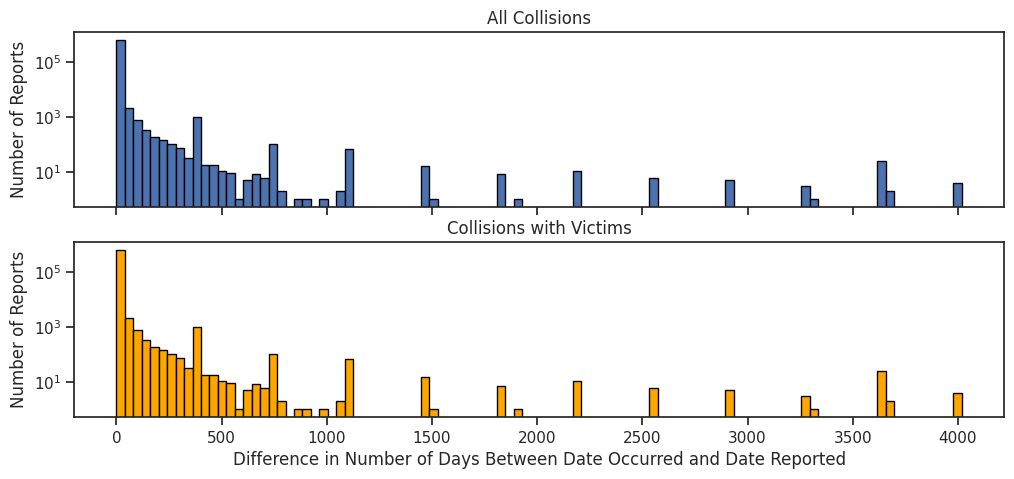

In [30]:
sns.set_theme(style="whitegrid")
sns.set_style("ticks")

figure, ax = plt.subplots(2,1, sharex=True, sharey=True, figsize=(12,5))
ax[0].hist(dat["reported_occurred_diff_int"],bins=100, edgecolor="black")
ax[0].set_yscale("log")
ax[0].set_ylabel("Number of Reports")
ax[0].set_title("All Collisions")
ax[0].grid(False)

ax[1].hist(dat[dat["victim"]]["reported_occurred_diff_int"],bins=100, edgecolor="black", color="orange")
ax[1].set_yscale("log")
ax[1].set_ylabel("Number of Reports")
ax[1].set_title("Collisions with Victims")
ax[1].set_xlabel("Difference in Number of Days Between Date Occurred and Date Reported")
ax[1].grid(False)

The DMV indicates that a report should be filed within 10 days if there were over $1,000 in property damage or someone was injured. About 2\% did not report within 10 days and 740 collisions which took more than a year to report. Additionally, if there were victims, I would expect the victims or the victims' families to report it earlier, but there was a similar pattern when there were victims and were not. Hence, I **made an assumption that these were transcription typos and that I would use the `date_occcurred` column for the analysis.**

In [31]:
(dat["reported_occurred_diff_int"]>=10).sum()/(dat["reported_occurred_diff_int"]).count()

np.float64(0.025556679754920965)

In [32]:
(dat["reported_occurred_diff_int"]>365).sum()

np.int64(866)

### Location (areas)

According to the data dictionary, the `area_id` and `area_name` are "The 21 Geographic Areas or Patrol Divisions are also given a name designation that references a landmark or the surrounding community that it is responsible for. For example 77th Street Division is located at the intersection of South Broadway and 77th Street, serving neighborhoods in South Los Angeles." As expected, I see that there is a 1:1 match from  `area_id` to `area_name`.

In [33]:
dat[["area_id","area_name"]].value_counts().sort_index()

,,count
area_id,area_name,
1,Central,26443
2,Rampart,23628
3,Southwest,36394
4,Hollenbeck,22665
5,Harbor,23373
6,Hollywood,29673
7,Wilshire,34640
8,West LA,32208
9,Van Nuys,30621


### Location (Reporting District)

The reporting district is "A code used in producing reports to group data into geographic sub-areas within an area. Find LAPD Reporting Districts on the [LA City GeoHub](http://geohub.lacity.org/datasets/c4f83909b81d4786aa8ba8a74a4b4db1_4)." They are used for organizing crimes into specific areas when reporting crime.

I downloaded the reporting district data from the [LA City Geohub](https://geohub.lacity.org/datasets/lahub::lapd-reporting-district/about).

In [34]:
dat["reporting_district"].value_counts().sort_index()

,count
reporting_district,
100,4
101,499
105,243
109,31
111,2501
...,...
2189,875
2196,168
2197,62


In [35]:
dfrd = pd.read_csv('LAPD_Reporting_Districts.csv')

In [36]:
dfrd.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1135 entries, 0 to 1134
Data columns (total 10 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   FID           1135 non-null   int64  
 1   REPDIST       1135 non-null   int64  
 2   PREC          1135 non-null   int64  
 3   APREC         1135 non-null   object 
 4   BUREAU        1135 non-null   object 
 5   BASICCAR      1135 non-null   object 
 6   AREA          1135 non-null   float64
 7   PERIMETER     1135 non-null   float64
 8   SHAPE_Length  1135 non-null   float64
 9   SHAPE_Area    1135 non-null   float64
dtypes: float64(4), int64(3), object(3)
memory usage: 88.8+ KB


In [37]:
dfrd.head()

,FID,REPDIST,PREC,APREC,BUREAU,BASICCAR,AREA,PERIMETER,SHAPE_Length,SHAPE_Area
0,1,1901,19,MISSION,VALLEY BUREAU,19A1,4.367178e+07,31946.355664,0.099163,0.000397
1,2,1705,17,DEVONSHIRE,VALLEY BUREAU,17A35,1.098543e+08,48888.592747,0.148847,0.001000
2,3,1902,19,MISSION,VALLEY BUREAU,19A7,3.353075e+07,26849.358596,0.081961,0.000305
3,4,1903,19,MISSION,VALLEY BUREAU,19A7,1.082610e+07,14488.784549,0.045659,0.000099
4,5,1904,19,MISSION,VALLEY BUREAU,19A7,1.730524e+07,20025.544413,0.061883,0.000157


In [38]:
dfrd["REPDIST"].value_counts().sort_index()

,count
REPDIST,
101,1
105,1
109,1
111,1
112,1
...,...
2189,1
2196,1
2197,1


In [39]:
dfrd["REPDIST"].value_counts()

,count
REPDIST,
1829,1
1901,1
1705,1
1902,1
1903,1
...,...
1919,1
1915,1
1921,1


`REPDIST` in this new data frame is also unique so it seems suitable that I use the `REPDIST` column as the foreign key in order to merge the data. I find that they are both numeric columns and judging by their abbreviation, should be the same item.

Thus, I needed to see if there are any reporting districts in the original data frame which aren't found in this reporting district data.

In [40]:
dat[~dat["reporting_district"].isin(dfrd["REPDIST"])]["reporting_district"].value_counts()

,count
reporting_district,
665,621
1942,129
1800,112
1400,98
500,57
...,...
1922,1
798,1
1900,1


There are 197 reporting districts which aren't in the new reporting district data I found. There also does not seem to be an even distribution of vehicle collisions in those reporting districts that are not found. Thus, I can use the reporting district columns, but if I do, I will be interpreting the results with caution.

In [41]:
dfrd.columns = ["rd_"+ col.lower() for col in dfrd.columns]
dfrd.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1135 entries, 0 to 1134
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   rd_fid           1135 non-null   int64  
 1   rd_repdist       1135 non-null   int64  
 2   rd_prec          1135 non-null   int64  
 3   rd_aprec         1135 non-null   object 
 4   rd_bureau        1135 non-null   object 
 5   rd_basiccar      1135 non-null   object 
 6   rd_area          1135 non-null   float64
 7   rd_perimeter     1135 non-null   float64
 8   rd_shape_length  1135 non-null   float64
 9   rd_shape_area    1135 non-null   float64
dtypes: float64(4), int64(3), object(3)
memory usage: 88.8+ KB


In [42]:
df_rd = pd.merge(dat, dfrd, how="left", left_on="reporting_district", right_on="rd_repdist")

In [43]:
df_rd.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 621677 entries, 0 to 621676
Data columns (total 33 columns):
 #   Column                      Non-Null Count   Dtype         
---  ------                      --------------   -----         
 0   dr_number                   621677 non-null  int64         
 1   date_reported               621677 non-null  object        
 2   date_occurred               621677 non-null  object        
 3   time_occurred               621677 non-null  object        
 4   area_id                     621677 non-null  int64         
 5   area_name                   621677 non-null  object        
 6   reporting_district          621677 non-null  int64         
 7   crime_code                  621677 non-null  int64         
 8   crime_code_description      621677 non-null  object        
 9   mo_codes                    534353 non-null  object        
 10  victim_age                  533483 non-null  float64       
 11  victim_sex                  610980 non-

In [44]:
df_rd[df_rd["rd_repdist"].isna()]["reporting_district"].value_counts()

,count
reporting_district,
665,621
1942,129
1800,112
1400,98
500,57
...,...
1922,1
798,1
1900,1


### Location (Premise)

Now, checking  by `premise_code` and `premise_description`.
* There is a 1:1 match except for `premise_code` 418 which has no description. When I examine the location by longitude and latitude coordinates, I find that other `premise_code`s in the same location are "street", "alley", and "parking lot".
* Most collisions occur on streets, parking lots, and sidewalks. There is a factor of 10 difference among the top 3.

In [45]:
df_rd[["premise_code","premise_description"]].value_counts()

,,count
premise_code,premise_description,
101.0,STREET,591306
108.0,PARKING LOT,19487
102.0,SIDEWALK,4183
103.0,ALLEY,1208
104.0,DRIVEWAY,1127
...,...,...
933.0,MTA - BLUE LINE - GRAND/LATTC,1
937.0,MTA - BLUE LINE - 103RD/WATTS TOWERS,1
956.0,MTA - GREEN LINE - AVALON,1


In [46]:
df_rd["premise_code"].value_counts()

,count
premise_code,
101.0,591306
108.0,19487
102.0,4183
103.0,1208
104.0,1127
...,...
719.0,1
119.0,1
222.0,1


In [47]:
df_rd["premise_description"].value_counts()

,count
premise_description,
STREET,591306
PARKING LOT,19487
SIDEWALK,4183
ALLEY,1208
DRIVEWAY,1127
...,...
MEDICAL/DENTAL OFFICES,1
"PORCH, RESIDENTIAL",1
LAUNDROMAT,1


In [48]:
df_rd[(~df_rd["premise_code"].isna()) & (df_rd["premise_description"].isna())]

,dr_number,date_reported,date_occurred,time_occurred,area_id,area_name,reporting_district,crime_code,crime_code_description,mo_codes,victim_age,victim_sex,victim_descent,premise_code,premise_description,address,cross_street,location,dttm_occurred,date_reported_dt,victim,reported_occurred_diff,reported_occurred_diff_int,rd_fid,rd_repdist,rd_prec,rd_aprec,rd_bureau,rd_basiccar,rd_area,rd_perimeter,rd_shape_length,rd_shape_area
50205,201213728,05/28/2020,05/28/2020,12:40,12,77th Street,1256,997,TRAFFIC COLLISION,1402,19.0,X,X,418.0,NaN,600 W FLORENCE AV,NaN,"(33.9747, -118.2838)",2020-05-28 12:40:00,2020-05-28,True,0:00:00,0,932.0,1256.0,12.0,77TH STREET,SOUTH BUREAU,12A57,5.732625e+06,10915.327085,0.034439,0.000052


In [49]:
df_rd[df_rd["location"]=="(33.9747, -118.2838)"][["premise_code","premise_description"]].value_counts()

,,count
premise_code,premise_description,
101.0,STREET,57
108.0,PARKING LOT,4
103.0,ALLEY,2


In [50]:
df_rd[df_rd["location"]=="(33.9747, -118.2838)"]

,dr_number,date_reported,date_occurred,time_occurred,area_id,area_name,reporting_district,crime_code,crime_code_description,mo_codes,victim_age,victim_sex,victim_descent,premise_code,premise_description,address,cross_street,location,dttm_occurred,date_reported_dt,victim,reported_occurred_diff,reported_occurred_diff_int,rd_fid,rd_repdist,rd_prec,rd_aprec,rd_bureau,rd_basiccar,rd_area,rd_perimeter,rd_shape_length,rd_shape_area
8443,201210862,04/13/2020,04/13/2020,19:15,12,77th Street,1249,997,TRAFFIC COLLISION,4012 3037 3004 3028 3030 3101,45.0,F,H,NaN,NaN,00,NaN,"(33.9747, -118.2838)",2020-04-13 19:15:00,2020-04-13,True,0:00:00,0,915.0,1249.0,12.0,77TH STREET,SOUTH BUREAU,12A49,5.989014e+06,10159.599780,0.030060,0.000054
10104,191222846,09/02/2019,09/01/2019,13:30,12,77th Street,1256,997,TRAFFIC COLLISION,0605,31.0,F,H,101.0,STREET,FLORENCE AV,DENVER AV,"(33.9747, -118.2838)",2019-09-01 13:30:00,2019-09-02,True,"1 day, 0:00:00",1,932.0,1256.0,12.0,77TH STREET,SOUTH BUREAU,12A57,5.732625e+06,10915.327085,0.034439,0.000052
20031,201218671,07/26/2020,07/25/2020,09:40,12,77th Street,1256,997,TRAFFIC COLLISION,NaN,28.0,M,H,101.0,STREET,W FLORENCE AV,DENVER AV,"(33.9747, -118.2838)",2020-07-25 09:40:00,2020-07-26,True,"1 day, 0:00:00",1,932.0,1256.0,12.0,77TH STREET,SOUTH BUREAU,12A57,5.732625e+06,10915.327085,0.034439,0.000052
34546,191228863,12/13/2019,12/13/2019,01:30,12,77th Street,1256,997,TRAFFIC COLLISION,4012 3036 3006 3028 3101 0605,30.0,M,B,101.0,STREET,FLORENCE AV,DENVER AV,"(33.9747, -118.2838)",2019-12-13 01:30:00,2019-12-13,True,0:00:00,0,932.0,1256.0,12.0,77TH STREET,SOUTH BUREAU,12A57,5.732625e+06,10915.327085,0.034439,0.000052
49906,201209542,03/22/2020,03/22/2020,15:15,12,77th Street,1249,997,TRAFFIC COLLISION,4025 3036 3004 3028 3030 3101,52.0,F,B,101.0,STREET,FLORENCE AV,DENVER AV,"(33.9747, -118.2838)",2020-03-22 15:15:00,2020-03-22,True,0:00:00,0,915.0,1249.0,12.0,77TH STREET,SOUTH BUREAU,12A49,5.989014e+06,10159.599780,0.030060,0.000054
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
568669,181229636,12/19/2018,12/19/2018,17:00,12,77th Street,1256,997,TRAFFIC COLLISION,4012 3036 3028 3004 3030 3101 0605,21.0,M,H,101.0,STREET,FLORENCE AV,DENVER AV,"(33.9747, -118.2838)",2018-12-19 17:00:00,2018-12-19,True,0:00:00,0,932.0,1256.0,12.0,77TH STREET,SOUTH BUREAU,12A57,5.732625e+06,10915.327085,0.034439,0.000052
601806,191209018,03/12/2019,03/12/2019,01:30,12,77th Street,1249,997,TRAFFIC COLLISION,3004 3028 3101 4012 3030 0605,22.0,M,B,101.0,STREET,FLORENCE,DENVER,"(33.9747, -118.2838)",2019-03-12 01:30:00,2019-03-12,True,0:00:00,0,915.0,1249.0,12.0,77TH STREET,SOUTH BUREAU,12A49,5.989014e+06,10159.599780,0.030060,0.000054
601906,191206689,02/08/2019,02/08/2019,10:30,12,77th Street,1249,997,TRAFFIC COLLISION,4025 3004 3026 3101,59.0,F,B,108.0,PARKING LOT,FLORENCE,DENVER,"(33.9747, -118.2838)",2019-02-08 10:30:00,2019-02-08,True,0:00:00,0,915.0,1249.0,12.0,77TH STREET,SOUTH BUREAU,12A49,5.989014e+06,10159.599780,0.030060,0.000054
602827,191211792,04/15/2019,04/15/2019,12:00,12,77th Street,1256,997,TRAFFIC COLLISION,3037 3004 3028 3030 3101 0605,49.0,F,B,101.0,STREET,FLORENCE AV,DENVER AV,"(33.9747, -118.2838)",2019-04-15 12:00:00,2019-04-15,True,0:00:00,0,932.0,1256.0,12.0,77TH STREET,SOUTH BUREAU,12A57,5.732625e+06,10915.327085,0.034439,0.000052


### Address (Misc)

Now, checking  by `address`, `cross_street`, and `location`.
   * `address` has the street name (and occasionally the number). There is an address for every record. I cleaned up the white space.
   * `cross_street` has records without a cross street. There are no corresponding records where there is an address found when there isn't a cross street. I cleaned up the white space.
   * For `location`, there are records with a location of (0.0, 0.0). At first glance, these look like they occur less often in `area_id` 4. The rest look within reason and there is a location for every row. **Thus, I replaced the (0,0) records with NA under the assumption that the location is invalid/non-reported.** I separated so that there is a latitude and longitude column.

In [51]:
df_rd["address"].value_counts(dropna=False)

,count
address,
WESTERN AV,8378
SHERMAN WY,7295
VENTURA BL,7290
SEPULVEDA BL,7056
VERMONT AV,6841
...,...
1000 E 59TH ST,1
3600 BEVERLY GLEN BL,1
SUN MUN WY,1


In [52]:
df_rd["address"].value_counts(dropna=False).sort_index()

,count
address,
0 ST,1
00,930
00 17TH AV,1
00 20TH AV,1
00 ANAHEIM ST,1
...,...
ZONAL ST,4
ZOO,29
ZOO DR,111


In [53]:
sum(df_rd["address"].isna())

0

In [54]:
df_rd["address_clean"] = df_rd["address"].replace(r'\s+',' ', regex=True)
df_rd["address_clean"].value_counts(dropna=False).sort_index()

,count
address_clean,
0 ST,1
00,930
00 17TH AV,1
00 20TH AV,1
00 ANAHEIM ST,1
...,...
ZONAL ST,4
ZOO,29
ZOO DR,111


In [55]:
df_rd["cross_street"].value_counts(dropna=False)

,count
cross_street,
NaN,29460
VERMONT AV,4611
FIGUEROA ST,4497
WESTERN AV,4361
SHERMAN WY,3618
...,...
HAZEL WY,1
KOSCIUZKO WY,1
FRONTENAC,1


In [56]:
df_rd[df_rd["location"].isin(df_rd[df_rd["cross_street"].isna()][["location"]])]

,dr_number,date_reported,date_occurred,time_occurred,area_id,area_name,reporting_district,crime_code,crime_code_description,mo_codes,victim_age,victim_sex,victim_descent,premise_code,premise_description,address,cross_street,location,dttm_occurred,date_reported_dt,victim,reported_occurred_diff,reported_occurred_diff_int,rd_fid,rd_repdist,rd_prec,rd_aprec,rd_bureau,rd_basiccar,rd_area,rd_perimeter,rd_shape_length,rd_shape_area,address_clean


In [57]:
df_rd[df_rd["address"].isin(df_rd[df_rd["cross_street"].isna()][["address"]])]

,dr_number,date_reported,date_occurred,time_occurred,area_id,area_name,reporting_district,crime_code,crime_code_description,mo_codes,victim_age,victim_sex,victim_descent,premise_code,premise_description,address,cross_street,location,dttm_occurred,date_reported_dt,victim,reported_occurred_diff,reported_occurred_diff_int,rd_fid,rd_repdist,rd_prec,rd_aprec,rd_bureau,rd_basiccar,rd_area,rd_perimeter,rd_shape_length,rd_shape_area,address_clean


In [58]:
df_rd["cross_street_clean"] = df_rd["cross_street"].replace(r'\s+',' ', regex=True)
df_rd["cross_street_clean"].value_counts(dropna=False).sort_index()

,count
cross_street_clean,
1 GATEWAYPLA,1
1 ST,4
1 ST ST,2
10,3
10 AV,1
...,...
ZOO DRIVE,1
ZORADA CT,1
ZORADA DR,1


In [59]:
df_rd["location"].value_counts(dropna=False).sort_index()

,count
location,
"(0.0, 0.0)",965
"(33.3427, -118.3258)",2
"(33.7065, -118.2879)",1
"(33.7065, -118.2928)",20
"(33.7065, -118.2929)",7
...,...
"(34.3797, -118.5286)",1
"(34.5957, -118.1784)",5
"(34.6012, -118.1605)",1


In [60]:
sum(df_rd["location"].isnull())

0

In [61]:
df_rd[df_rd["location"]=="(0.0, 0.0)"]["area_id"].value_counts().sort_index()

,count
area_id,
1,47
2,20
3,37
4,22
5,37
6,18
7,31
8,58
9,60


In [62]:
df_rd["area_id"].value_counts().sort_index()

,count
area_id,
1,26443
2,23628
3,36394
4,22665
5,23373
6,29673
7,34640
8,32208
9,30621


In [63]:
df_rd["location_clean"] = df_rd["location"].replace('(0.0, 0.0)', np.nan)
df_rd["location_clean"].value_counts(dropna=False).sort_index()

,count
location_clean,
"(33.3427, -118.3258)",2
"(33.7065, -118.2879)",1
"(33.7065, -118.2928)",20
"(33.7065, -118.2929)",7
"(33.7067, -118.2879)",4
...,...
"(34.5957, -118.1784)",5
"(34.6012, -118.1605)",1
"(34.6903, -118.3053)",1


In [64]:
df_rd[["latitude", "longitude"]] = df_rd["location_clean"].str.split(",", expand=True)
# df_rd["latitude"]
df_rd["latitude"] = df_rd["latitude"].str.replace("(","", regex=False)
df_rd["longitude"] = df_rd["longitude"].str.replace(")","", regex=False)

df_rd["latitude"] = pd.to_numeric(df_rd["latitude"])
df_rd["longitude"] = pd.to_numeric(df_rd["longitude"])

df_rd.head()

,dr_number,date_reported,date_occurred,time_occurred,area_id,area_name,reporting_district,crime_code,crime_code_description,mo_codes,victim_age,victim_sex,victim_descent,premise_code,premise_description,address,cross_street,location,dttm_occurred,date_reported_dt,victim,reported_occurred_diff,reported_occurred_diff_int,rd_fid,rd_repdist,rd_prec,rd_aprec,rd_bureau,rd_basiccar,rd_area,rd_perimeter,rd_shape_length,rd_shape_area,address_clean,cross_street_clean,location_clean,latitude,longitude
0,212013850,09/03/2021,09/02/2021,23:35,20,Olympic,2021,997,TRAFFIC COLLISION,3004 3027 3034 4027 3036 3101 3401 3701,25.0,F,W,101.0,STREET,WILTON PL,6TH ST,"(34.063, -118.3141)",2021-09-02 23:35:00,2021-09-03,True,"1 day, 0:00:00",1,587.0,2021.0,20.0,OLYMPIC,WEST BUREAU,20A1,7.271800e+06,11404.738255,0.034704,0.000066,WILTON PL,6TH ST,"(34.063, -118.3141)",34.0630,-118.3141
1,221417787,10/17/2022,10/17/2022,16:20,14,Pacific,1406,997,TRAFFIC COLLISION,4027 3011 3028 3034 3037 3101 3401 3701,21.0,NaN,NaN,101.0,STREET,NATIONAL BL,MOTOR AV,"(34.029, -118.4113)",2022-10-17 16:20:00,2022-10-17,True,0:00:00,0,784.0,1406.0,14.0,PACIFIC,WEST BUREAU,14A27,5.930154e+06,13871.239038,0.041177,0.000054,NATIONAL BL,MOTOR AV,"(34.029, -118.4113)",34.0290,-118.4113
2,221418141,10/26/2022,10/26/2022,11:35,14,Pacific,1434,997,TRAFFIC COLLISION,4027 3011 3025 3034 3037 3101 3401 3701,21.0,NaN,NaN,101.0,STREET,PALMS BL,ROSEWOOD AV,"(34.0052, -118.4478)",2022-10-26 11:35:00,2022-10-26,True,0:00:00,0,851.0,1434.0,14.0,PACIFIC,WEST BUREAU,14A25,1.270249e+07,14745.407361,0.045077,0.000115,PALMS BL,ROSEWOOD AV,"(34.0052, -118.4478)",34.0052,-118.4478
3,222017859,12/01/2022,12/01/2022,02:30,20,Olympic,2044,997,TRAFFIC COLLISION,3003 0913 3026 3035 3037 3101 3401 3701 4020,33.0,M,H,101.0,STREET,IROLO ST,SAN MARINO ST,"(34.0545, -118.3009)",2022-12-01 02:30:00,2022-12-01,True,0:00:00,0,639.0,2044.0,20.0,OLYMPIC,WEST BUREAU,20A33,1.548755e+06,4963.554266,0.015091,0.000014,IROLO ST,SAN MARINO ST,"(34.0545, -118.3009)",34.0545,-118.3009
4,190319651,08/24/2019,08/24/2019,04:50,3,Southwest,356,997,TRAFFIC COLLISION,3036 3004 3026 3101 4003,22.0,M,H,101.0,STREET,JEFFERSON BL,NORMANDIE AV,"(34.0255, -118.3002)",2019-08-24 04:50:00,2019-08-24,True,0:00:00,0,808.0,356.0,3.0,SOUTHWEST,SOUTH BUREAU,3A55,7.018806e+06,10591.266020,0.032011,0.000064,JEFFERSON BL,NORMANDIE AV,"(34.0255, -118.3002)",34.0255,-118.3002


### Crime code and description
Now, I need to check the `crime_code` and `crime_code_description`. I find that they are all 997 and "TRAFFIC COLLISION" respectively. This matches the data dictionary and I can assume that this is the filter that was applied to generate this dataset.

In [65]:
df_rd["crime_code"].value_counts()

,count
crime_code,
997,621677


In [66]:
df_rd["crime_code_description"].value_counts()

,count
crime_code_description,
TRAFFIC COLLISION,621677


Because these columns do not provide any useful information to the analysis, I decided to drop them.

In [67]:
df_rd.drop(columns=["crime_code","crime_code_description"], inplace=True)
df_rd.head()

,dr_number,date_reported,date_occurred,time_occurred,area_id,area_name,reporting_district,mo_codes,victim_age,victim_sex,victim_descent,premise_code,premise_description,address,cross_street,location,dttm_occurred,date_reported_dt,victim,reported_occurred_diff,reported_occurred_diff_int,rd_fid,rd_repdist,rd_prec,rd_aprec,rd_bureau,rd_basiccar,rd_area,rd_perimeter,rd_shape_length,rd_shape_area,address_clean,cross_street_clean,location_clean,latitude,longitude
0,212013850,09/03/2021,09/02/2021,23:35,20,Olympic,2021,3004 3027 3034 4027 3036 3101 3401 3701,25.0,F,W,101.0,STREET,WILTON PL,6TH ST,"(34.063, -118.3141)",2021-09-02 23:35:00,2021-09-03,True,"1 day, 0:00:00",1,587.0,2021.0,20.0,OLYMPIC,WEST BUREAU,20A1,7.271800e+06,11404.738255,0.034704,0.000066,WILTON PL,6TH ST,"(34.063, -118.3141)",34.0630,-118.3141
1,221417787,10/17/2022,10/17/2022,16:20,14,Pacific,1406,4027 3011 3028 3034 3037 3101 3401 3701,21.0,NaN,NaN,101.0,STREET,NATIONAL BL,MOTOR AV,"(34.029, -118.4113)",2022-10-17 16:20:00,2022-10-17,True,0:00:00,0,784.0,1406.0,14.0,PACIFIC,WEST BUREAU,14A27,5.930154e+06,13871.239038,0.041177,0.000054,NATIONAL BL,MOTOR AV,"(34.029, -118.4113)",34.0290,-118.4113
2,221418141,10/26/2022,10/26/2022,11:35,14,Pacific,1434,4027 3011 3025 3034 3037 3101 3401 3701,21.0,NaN,NaN,101.0,STREET,PALMS BL,ROSEWOOD AV,"(34.0052, -118.4478)",2022-10-26 11:35:00,2022-10-26,True,0:00:00,0,851.0,1434.0,14.0,PACIFIC,WEST BUREAU,14A25,1.270249e+07,14745.407361,0.045077,0.000115,PALMS BL,ROSEWOOD AV,"(34.0052, -118.4478)",34.0052,-118.4478
3,222017859,12/01/2022,12/01/2022,02:30,20,Olympic,2044,3003 0913 3026 3035 3037 3101 3401 3701 4020,33.0,M,H,101.0,STREET,IROLO ST,SAN MARINO ST,"(34.0545, -118.3009)",2022-12-01 02:30:00,2022-12-01,True,0:00:00,0,639.0,2044.0,20.0,OLYMPIC,WEST BUREAU,20A33,1.548755e+06,4963.554266,0.015091,0.000014,IROLO ST,SAN MARINO ST,"(34.0545, -118.3009)",34.0545,-118.3009
4,190319651,08/24/2019,08/24/2019,04:50,3,Southwest,356,3036 3004 3026 3101 4003,22.0,M,H,101.0,STREET,JEFFERSON BL,NORMANDIE AV,"(34.0255, -118.3002)",2019-08-24 04:50:00,2019-08-24,True,0:00:00,0,808.0,356.0,3.0,SOUTHWEST,SOUTH BUREAU,3A55,7.018806e+06,10591.266020,0.032011,0.000064,JEFFERSON BL,NORMANDIE AV,"(34.0255, -118.3002)",34.0255,-118.3002


### Victim Information

Now, checking  by `victim_age`, `victim_sex`, and `victim_descent` if one exists based on my prior assumptions of one victim per collision and that at least one of the victim columns is filled out.
   * Looking at `victim_age`, it has a character limit of two-characters. It is possible for a victim to be over 100 years old, but very few people live to be over 100 years old. Due to the distribution, I will **assume that 99 is a catch-all code.**
   * Regarding `victim_sex`, according to the data dictionary, F=Female, M=Male, X=Other/Unknown. I do not know what H and N correspond to though **so I will assume it is a typo and will re-code them as "Other/Unknown"**. There are also null values.
   * For `victim_descent`, there are "-" which I **assume is a miscoding and therefore will recode as "X: Unknown"** and null values. The rest match the data dictionary.

**Victim Age**

In [68]:
df_rd[(df_rd["victim_age"].isna()) & (df_rd["victim_sex"].isna()) & (df_rd["victim_descent"].isna())]

,dr_number,date_reported,date_occurred,time_occurred,area_id,area_name,reporting_district,mo_codes,victim_age,victim_sex,victim_descent,premise_code,premise_description,address,cross_street,location,dttm_occurred,date_reported_dt,victim,reported_occurred_diff,reported_occurred_diff_int,rd_fid,rd_repdist,rd_prec,rd_aprec,rd_bureau,rd_basiccar,rd_area,rd_perimeter,rd_shape_length,rd_shape_area,address_clean,cross_street_clean,location_clean,latitude,longitude
267,230507342,04/03/2023,04/02/2023,23:55,5,Harbor,516,3003 3024 4005 3029 1218,NaN,NaN,NaN,101.0,STREET,AVALON,I ST,"(33.7868, -118.2658)",2023-04-02 23:55:00,2023-04-03,False,"1 day, 0:00:00",1,1011.0,516.0,5.0,HARBOR,SOUTH BUREAU,5A15,5.205897e+06,9529.490169,0.028093,0.000047,AVALON,I ST,"(33.7868, -118.2658)",33.7868,-118.2658
402,191613359,08/31/2019,08/30/2019,22:20,16,Foothill,1653,3037 3011 3024 3034 3101 3401 3701 4026,NaN,NaN,NaN,101.0,STREET,MONTAGUE ST,SAN FERNANDO RD,"(34.2512, -118.4063)",2019-08-30 22:20:00,2019-08-31,False,"1 day, 0:00:00",1,110.0,1653.0,16.0,FOOTHILL,VALLEY BUREAU,16A23,1.206978e+07,14232.469967,0.043173,0.000110,MONTAGUE ST,SAN FERNANDO RD,"(34.2512, -118.4063)",34.2512,-118.4063
1038,191715008,09/07/2019,09/07/2019,11:00,17,Devonshire,1701,NaN,NaN,NaN,NaN,108.0,PARKING LOT,RINALDI ST,CORBIN AV,"(34.2748, -118.5621)",2019-09-07 11:00:00,2019-09-07,False,0:00:00,0,21.0,1701.0,17.0,DEVONSHIRE,VALLEY BUREAU,17A23,9.811502e+07,47488.979227,0.145497,0.000893,RINALDI ST,CORBIN AV,"(34.2748, -118.5621)",34.2748,-118.5621
2464,201409246,04/03/2020,04/03/2020,20:50,14,Pacific,1496,3011 3028 3034 3037 3101 3401 3701 4014,NaN,NaN,NaN,NaN,NaN,00,NaN,"(33.9474, -118.3961)",2020-04-03 20:50:00,2020-04-03,False,0:00:00,0,970.0,1496.0,14.0,PACIFIC,WEST BUREAU,14A67,3.821328e+06,8810.972220,0.027594,0.000035,00,NaN,"(33.9474, -118.3961)",33.9474,-118.3961
2569,201707954,04/05/2020,04/05/2020,05:00,17,Devonshire,1777,3011 3027 3037 3101 4026,NaN,NaN,NaN,101.0,STREET,NORDHOFF ST,GOTHIC AV,"(34.2357, -118.4895)",2020-04-05 05:00:00,2020-04-05,False,0:00:00,0,128.0,1777.0,17.0,DEVONSHIRE,VALLEY BUREAU,17A95,1.431905e+07,16189.022322,0.047816,0.000130,NORDHOFF ST,GOTHIC AV,"(34.2357, -118.4895)",34.2357,-118.4895
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
619284,240913430,12/04/2024,12/04/2024,03:20,9,Van Nuys,974,3006 3028 4009 3039,NaN,NaN,NaN,101.0,STREET,4700 VAN NUYS BL,NaN,"(34.156, -118.4487)",2024-12-04 03:20:00,2024-12-04,False,0:00:00,0,361.0,974.0,9.0,VAN NUYS,VALLEY BUREAU,9A63,5.820260e+06,9840.741505,0.029925,0.000053,4700 VAN NUYS BL,NaN,"(34.156, -118.4487)",34.1560,-118.4487
619606,251504106,01/10/2025,01/10/2025,13:10,15,N Hollywood,1525,3004 3026 4015 3033 3034 3037,NaN,NaN,NaN,101.0,STREET,LAUREL CANYON BL,ERWIN ST,"(34.183, -118.3965)",2025-01-10 13:10:00,2025-01-10,False,0:00:00,0,287.0,1525.0,15.0,NORTH HOLLYWOOD,VALLEY BUREAU,15A33,1.436660e+07,17005.929374,0.049214,0.000131,LAUREL CANYON BL,ERWIN ST,"(34.183, -118.3965)",34.1830,-118.3965
619700,251904070,01/27/2025,01/27/2025,20:40,19,Mission,1994,3101 3004 3028 3034 3037 4026,NaN,NaN,NaN,101.0,STREET,VAN NUYS,ROSCOE,"(34.2215, -118.4488)",2025-01-27 20:40:00,2025-01-27,False,0:00:00,0,192.0,1994.0,19.0,MISSION,VALLEY BUREAU,19A93,5.903088e+06,16281.914167,0.050412,0.000054,VAN NUYS,ROSCOE,"(34.2215, -118.4488)",34.2215,-118.4488
619877,250904064,01/27/2025,01/27/2025,02:00,9,Van Nuys,915,3101 3011 3028 4026 3030 3034 3037,NaN,NaN,NaN,101.0,STREET,LENNOX AV,N VANOWEN ST,"(34.1939, -118.4455)",2025-01-27 02:00:00,2025-01-27,False,0:00:00,0,256.0,915.0,9.0,VAN NUYS,VALLEY BUREAU,9A19,6.963540e+06,10567.354316,0.031984,0.000063,LENNOX AV,N VANOWEN ST,"(34.1939, -118.4455)",34.1939,-118.4455


In [69]:
df_rd[(df_rd["victim_age"].notna()) | (df_rd["victim_sex"].notna()) | (df_rd["victim_descent"].notna())].shape

(615192, 36)

In [70]:
# Victim age
print('Number of victim_age rows with NA:', sum(df_rd["victim_age"].isna()))
df_rd["victim_age"].value_counts().sort_index()

Number of victim_age rows with NA: 88194


,count
victim_age,
10.0,122
11.0,107
12.0,144
13.0,148
14.0,194
...,...
95.0,56
96.0,47
97.0,36


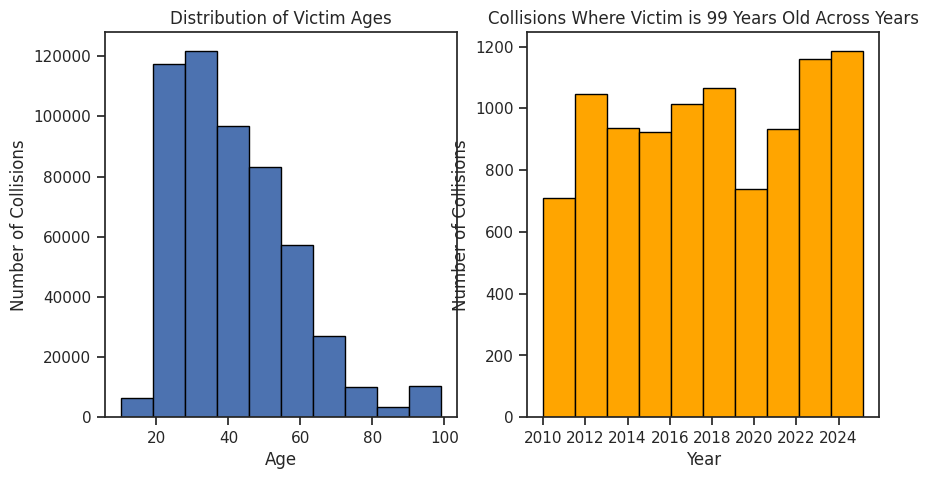

In [71]:
sns.set_theme(style="whitegrid")
sns.set_style("ticks")

figure, ax = plt.subplots(1,2, sharex=False, sharey=False, figsize=(10,5))
ax[0].hist(df_rd["victim_age"],bins=10, edgecolor="black")
ax[0].set_ylabel("Number of Collisions")
ax[0].set_xlabel("Age")
ax[0].set_title("Distribution of Victim Ages")
ax[0].grid(False)

ax[1].hist(df_rd[df_rd["victim_age"]==99]["dttm_occurred"],bins=10, edgecolor="black", color="orange")
ax[1].set_ylabel("Number of Collisions")
ax[1].set_title("Collisions Where Victim is 99 Years Old Across Years")
ax[1].set_xlabel("Year")
ax[1].grid(False)

plt.show()

**Victim Sex**

In [72]:
print('Number of victim_sex rows with NA:', sum(df_rd["victim_sex"].isna()))
df_rd["victim_sex"].value_counts(dropna=False).sort_index()

Number of victim_sex rows with NA: 10697


,count
victim_sex,
-,1
F,226576
H,186
M,366612
N,11
X,17594
NaN,10697


In [73]:
sexdict = dict(F="Female", M="Male", X="Other/Unknown", H="Other/Unknown", N="Other/Unknown")
df_rd['victim_sex_clean'] = df_rd.victim_sex.replace(sexdict)
df_rd.victim_sex_clean.value_counts(dropna=False).sort_index()

,count
victim_sex_clean,
-,1
Female,226576
Male,366612
Other/Unknown,17791
NaN,10697


**Victim Descent**

In [74]:
print("Number of null victim descents:", df_rd["victim_descent"].isna().sum())
df_rd["victim_descent"].value_counts().sort_index()

Number of null victim descents: 11648


,count
victim_descent,
-,3
A,22325
B,82238
C,918
D,17
F,1776
G,52
H,235060
I,186


Additionally, Asians and Native Hawaiian and Pacific Islanders had more specific descent groups. In order to make it more comparable, I decided to use the groupings the US Census uses: White, Black, American Indian/Alaska Native, Asian, Native Hawaiian or Pacific Islander, and other.

Unfortunately, this means I am still comparing race and ethnicity which are not the same.

In [75]:
# Decode victim descent
descent_dict = {"A":"Other Asian",
                "B":"Black",
                "C":"Chinese",
                "D":"Cambodian",
                "F":"Filipino",
                "G":"Guamanian",
                "H":"Hispanic/Latin/Mexican",
                "I":"American Indian/Alaskan Native",
                "J":"Japanese",
                "K":"Korean",
                "L":"Laotian",
                "O":"Other",
                "P":"Pacific Islander",
                "S":"Samoan",
                "U":"Hawaiian",
                "V":"Vietnamese",
                "W":"White",
                "X":"Unknown",
                "Z":"Asian Indian",
                "-":"Unknown"}
descent_dict2 = {"A":"Asian", #Other Asian
                "B":"Black",
                "C":"Asian", #Chinese
                "D":"Asian", #Cambodian
                "F":"Native Hawaiian/Pacific Islander", #Filipino
                "G":"Native Hawaiian/Pacific Islander", #Guamanian
                "H":"Hispanic/Latin/Mexican",
                "I":"American Indian/Alaskan Native",
                "J":"Asian", #Japanese
                "K":"Asian", #Korean
                "L":"Asian", #Laotian
                "O":"Other",
                "P":"Native Hawaiian/Pacific Islander", #Pacific Islander
                "S":"Native Hawaiian/Pacific Islander", #Samoan
                "U":"Native Hawaiian/Pacific Islander", #Hawaiian
                "V":"Asian", #Vietnamese
                "W":"White",
                "X":"Unknown",
                "Z":"Asian", #Asian Indian
                "-":"Unknown"}
df_rd['victim_descent_clean'] = df_rd.victim_descent.replace(descent_dict2)
df_rd['victim_descent_clean'].value_counts(dropna=False).sort_index()

,count
victim_descent_clean,
American Indian/Alaskan Native,186
Asian,28581
Black,82238
Hispanic/Latin/Mexican,235060
Native Hawaiian/Pacific Islander,2549
Other,90589
Unknown,29921
White,140905
NaN,11648


### MO Codes

Now, checking the `mo_codes`. Since there are multiple MO codes in the same column, I created a separate copy of the data frame so I can examine the MO codes by themselves without changing the original dataset too much.

There are MO codes that do not have a corresponding definition. **I will assume these were mistyped or mistranscribed. I will move forward by recoding the MO code as NaN.**

In [76]:
df_rd_copy = deepcopy(df_rd)
df_rd_copy[["mo_code_0",
            "mo_code_1",
            "mo_code_2",
            "mo_code_3",
            "mo_code_4",
            "mo_code_5",
            "mo_code_6",
            "mo_code_7",
            "mo_code_8",
            "mo_code_9"]] = df_rd_copy["mo_codes"].str.split(" ", expand=True)

df_rd_copy.head()

,dr_number,date_reported,date_occurred,time_occurred,area_id,area_name,reporting_district,mo_codes,victim_age,victim_sex,victim_descent,premise_code,premise_description,address,cross_street,location,dttm_occurred,date_reported_dt,victim,reported_occurred_diff,reported_occurred_diff_int,rd_fid,rd_repdist,rd_prec,rd_aprec,rd_bureau,rd_basiccar,rd_area,rd_perimeter,rd_shape_length,rd_shape_area,address_clean,cross_street_clean,location_clean,latitude,longitude,victim_sex_clean,victim_descent_clean,mo_code_0,mo_code_1,mo_code_2,mo_code_3,mo_code_4,mo_code_5,mo_code_6,mo_code_7,mo_code_8,mo_code_9
0,212013850,09/03/2021,09/02/2021,23:35,20,Olympic,2021,3004 3027 3034 4027 3036 3101 3401 3701,25.0,F,W,101.0,STREET,WILTON PL,6TH ST,"(34.063, -118.3141)",2021-09-02 23:35:00,2021-09-03,True,"1 day, 0:00:00",1,587.0,2021.0,20.0,OLYMPIC,WEST BUREAU,20A1,7.271800e+06,11404.738255,0.034704,0.000066,WILTON PL,6TH ST,"(34.063, -118.3141)",34.0630,-118.3141,Female,White,3004,3027,3034,4027,3036,3101,3401,3701,None,None
1,221417787,10/17/2022,10/17/2022,16:20,14,Pacific,1406,4027 3011 3028 3034 3037 3101 3401 3701,21.0,NaN,NaN,101.0,STREET,NATIONAL BL,MOTOR AV,"(34.029, -118.4113)",2022-10-17 16:20:00,2022-10-17,True,0:00:00,0,784.0,1406.0,14.0,PACIFIC,WEST BUREAU,14A27,5.930154e+06,13871.239038,0.041177,0.000054,NATIONAL BL,MOTOR AV,"(34.029, -118.4113)",34.0290,-118.4113,NaN,NaN,4027,3011,3028,3034,3037,3101,3401,3701,None,None
2,221418141,10/26/2022,10/26/2022,11:35,14,Pacific,1434,4027 3011 3025 3034 3037 3101 3401 3701,21.0,NaN,NaN,101.0,STREET,PALMS BL,ROSEWOOD AV,"(34.0052, -118.4478)",2022-10-26 11:35:00,2022-10-26,True,0:00:00,0,851.0,1434.0,14.0,PACIFIC,WEST BUREAU,14A25,1.270249e+07,14745.407361,0.045077,0.000115,PALMS BL,ROSEWOOD AV,"(34.0052, -118.4478)",34.0052,-118.4478,NaN,NaN,4027,3011,3025,3034,3037,3101,3401,3701,None,None
3,222017859,12/01/2022,12/01/2022,02:30,20,Olympic,2044,3003 0913 3026 3035 3037 3101 3401 3701 4020,33.0,M,H,101.0,STREET,IROLO ST,SAN MARINO ST,"(34.0545, -118.3009)",2022-12-01 02:30:00,2022-12-01,True,0:00:00,0,639.0,2044.0,20.0,OLYMPIC,WEST BUREAU,20A33,1.548755e+06,4963.554266,0.015091,0.000014,IROLO ST,SAN MARINO ST,"(34.0545, -118.3009)",34.0545,-118.3009,Male,Hispanic/Latin/Mexican,3003,0913,3026,3035,3037,3101,3401,3701,4020,None
4,190319651,08/24/2019,08/24/2019,04:50,3,Southwest,356,3036 3004 3026 3101 4003,22.0,M,H,101.0,STREET,JEFFERSON BL,NORMANDIE AV,"(34.0255, -118.3002)",2019-08-24 04:50:00,2019-08-24,True,0:00:00,0,808.0,356.0,3.0,SOUTHWEST,SOUTH BUREAU,3A55,7.018806e+06,10591.266020,0.032011,0.000064,JEFFERSON BL,NORMANDIE AV,"(34.0255, -118.3002)",34.0255,-118.3002,Male,Hispanic/Latin/Mexican,3036,3004,3026,3101,4003,None,None,None,None,None


In [77]:
dfrd_mo_long = pd.melt(df_rd_copy, id_vars=["dr_number"], value_vars = ["mo_code_0",
                                                                        "mo_code_1",
                                                                        "mo_code_2",
                                                                        "mo_code_3",
                                                                        "mo_code_4",
                                                                        "mo_code_5",
                                                                        "mo_code_6",
                                                                        "mo_code_7",
                                                                        "mo_code_8",
                                                                        "mo_code_9",])
dfrd_mo_long.columns = ["dr_number","orig_var","mo_code"]
dfrd_mo_long.mo_code.value_counts() # 333 mo_codes, max is 3101 with 419,587

,count
mo_code,
3101,454441
3401,361373
3701,361237
3004,268791
3037,252159
...,...
0366,1
2150,1
2315,1


In [78]:
# check what happens to the "None" values when they are melted.
# 190319651 only has 3036, 3004, 3026, 3101, 4003
dfrd_mo_long[dfrd_mo_long.dr_number==190319651]
dfrd_mo_long.dropna(subset=["mo_code"], inplace=True)
dfrd_mo_long.shape #3182316

dfrd_mo_long[["dr_number","mo_code"]].value_counts() #there are unique dr_numbers to mo_codes.

,,count
dr_number,mo_code,
252104133,4021,1
100101322,1402,1
100104092,0605,1
100104510,0605,1
100104932,0605,1
...,...,...
100108868,0605,1
100108631,0605,1
100107008,1501,1


I checked if every `mo_code` found in the dataset exists in the mo_code_dictionary but I found that not all of them exist in the dictionary.

In [79]:
dfrd_mo_desc = pd.merge(dfrd_mo_long,
                        mo_codes_dict,
                        left_on="mo_code",
                        right_on="mo_code",
                        how="left")
dfrd_mo_desc.shape
dfrd_mo_desc

,dr_number,orig_var,mo_code,code_def
0,212013850,mo_code_0,3004,T/C - Veh vs Veh
1,221417787,mo_code_0,4027,T/C - West Traffic (WTD)
2,221418141,mo_code_0,4027,T/C - West Traffic (WTD)
3,222017859,mo_code_0,3003,T/C - Veh vs Ped
4,190319651,mo_code_0,3036,T/C - At Intersection - Yes
...,...,...,...,...
3523091,251304193,mo_code_9,4024,T/C - Central Traffic (CTD)
3523092,250104244,mo_code_9,4024,T/C - Central Traffic (CTD)
3523093,250104227,mo_code_9,3401,T/C - Type of Collision
3523094,250104238,mo_code_9,4024,T/C - Central Traffic (CTD)


In [80]:
dfrd_mo_desc[["mo_code","code_def"]].value_counts()

,,count
mo_code,code_def,
3101,T/C - PCF (A) In the Narrative,454441
3401,T/C - Type of Collision,361373
3701,T/C - Movement Preceding Collision,361237
3004,T/C - Veh vs Veh,268791
3037,T/C - At Intersection - No,252159
...,...,...
0360,Suspect is Other Family Member,1
0310,Got victim to withdraw savings,1
0309,Drive-by shooting,1


In [81]:
print(f'Number of MO Codes without a description: {dfrd_mo_desc["code_def"].isnull().sum()}') #841 are NaN values.
print("")
dfrd_mo_desc[dfrd_mo_desc["code_def"].isnull()]["mo_code"].value_counts()

Number of MO Codes without a description: 1602



,count
mo_code,
0947,1103
3064,307
3063,116
3031,71
1505,1
1513,1
2055,1
2053,1
1528,1


In [82]:
null_mo = dfrd_mo_desc[dfrd_mo_desc["code_def"].isnull()]["mo_code"].unique()
dfrd_mo_desc['mo_code_clean'] = np.where(dfrd_mo_desc['mo_code'].isin(null_mo),np.nan,dfrd_mo_desc['mo_code'])

In [83]:
dfrd_mo_desc['mo_code_clean'].value_counts()

,count
mo_code_clean,
3101,454441
3401,361373
3701,361237
3004,268791
3037,252159
...,...
1903,1
1303,1
0310,1


In [84]:
dfrd_mo_desc['mo_code_clean'].isin(null_mo).value_counts()

,count
mo_code_clean,
False,3523096


In [85]:
dfrd_mo_desc.dropna(subset=["mo_code_clean"])

,dr_number,orig_var,mo_code,code_def,mo_code_clean
0,212013850,mo_code_0,3004,T/C - Veh vs Veh,3004
1,221417787,mo_code_0,4027,T/C - West Traffic (WTD),4027
2,221418141,mo_code_0,4027,T/C - West Traffic (WTD),4027
3,222017859,mo_code_0,3003,T/C - Veh vs Ped,3003
4,190319651,mo_code_0,3036,T/C - At Intersection - Yes,3036
...,...,...,...,...,...
3523091,251304193,mo_code_9,4024,T/C - Central Traffic (CTD),4024
3523092,250104244,mo_code_9,4024,T/C - Central Traffic (CTD),4024
3523093,250104227,mo_code_9,3401,T/C - Type of Collision,3401
3523094,250104238,mo_code_9,4024,T/C - Central Traffic (CTD),4024


In [86]:
dfin = df_rd
mo_fin = dfrd_mo_desc[dfrd_mo_desc["dr_number"].isin(dfin["dr_number"])]
mo_fin

,dr_number,orig_var,mo_code,code_def,mo_code_clean
0,212013850,mo_code_0,3004,T/C - Veh vs Veh,3004
1,221417787,mo_code_0,4027,T/C - West Traffic (WTD),4027
2,221418141,mo_code_0,4027,T/C - West Traffic (WTD),4027
3,222017859,mo_code_0,3003,T/C - Veh vs Ped,3003
4,190319651,mo_code_0,3036,T/C - At Intersection - Yes,3036
...,...,...,...,...,...
3523091,251304193,mo_code_9,4024,T/C - Central Traffic (CTD),4024
3523092,250104244,mo_code_9,4024,T/C - Central Traffic (CTD),4024
3523093,250104227,mo_code_9,3401,T/C - Type of Collision,3401
3523094,250104238,mo_code_9,4024,T/C - Central Traffic (CTD),4024


# Final Dataset
I am now left with the final dataframes: `dfin` and `dfrd_mo_desc`.

In [87]:
print("Shape:", dfin.shape)
dfin.head()

Shape: (621677, 38)


,dr_number,date_reported,date_occurred,time_occurred,area_id,area_name,reporting_district,mo_codes,victim_age,victim_sex,victim_descent,premise_code,premise_description,address,cross_street,location,dttm_occurred,date_reported_dt,victim,reported_occurred_diff,reported_occurred_diff_int,rd_fid,rd_repdist,rd_prec,rd_aprec,rd_bureau,rd_basiccar,rd_area,rd_perimeter,rd_shape_length,rd_shape_area,address_clean,cross_street_clean,location_clean,latitude,longitude,victim_sex_clean,victim_descent_clean
0,212013850,09/03/2021,09/02/2021,23:35,20,Olympic,2021,3004 3027 3034 4027 3036 3101 3401 3701,25.0,F,W,101.0,STREET,WILTON PL,6TH ST,"(34.063, -118.3141)",2021-09-02 23:35:00,2021-09-03,True,"1 day, 0:00:00",1,587.0,2021.0,20.0,OLYMPIC,WEST BUREAU,20A1,7.271800e+06,11404.738255,0.034704,0.000066,WILTON PL,6TH ST,"(34.063, -118.3141)",34.0630,-118.3141,Female,White
1,221417787,10/17/2022,10/17/2022,16:20,14,Pacific,1406,4027 3011 3028 3034 3037 3101 3401 3701,21.0,NaN,NaN,101.0,STREET,NATIONAL BL,MOTOR AV,"(34.029, -118.4113)",2022-10-17 16:20:00,2022-10-17,True,0:00:00,0,784.0,1406.0,14.0,PACIFIC,WEST BUREAU,14A27,5.930154e+06,13871.239038,0.041177,0.000054,NATIONAL BL,MOTOR AV,"(34.029, -118.4113)",34.0290,-118.4113,NaN,NaN
2,221418141,10/26/2022,10/26/2022,11:35,14,Pacific,1434,4027 3011 3025 3034 3037 3101 3401 3701,21.0,NaN,NaN,101.0,STREET,PALMS BL,ROSEWOOD AV,"(34.0052, -118.4478)",2022-10-26 11:35:00,2022-10-26,True,0:00:00,0,851.0,1434.0,14.0,PACIFIC,WEST BUREAU,14A25,1.270249e+07,14745.407361,0.045077,0.000115,PALMS BL,ROSEWOOD AV,"(34.0052, -118.4478)",34.0052,-118.4478,NaN,NaN
3,222017859,12/01/2022,12/01/2022,02:30,20,Olympic,2044,3003 0913 3026 3035 3037 3101 3401 3701 4020,33.0,M,H,101.0,STREET,IROLO ST,SAN MARINO ST,"(34.0545, -118.3009)",2022-12-01 02:30:00,2022-12-01,True,0:00:00,0,639.0,2044.0,20.0,OLYMPIC,WEST BUREAU,20A33,1.548755e+06,4963.554266,0.015091,0.000014,IROLO ST,SAN MARINO ST,"(34.0545, -118.3009)",34.0545,-118.3009,Male,Hispanic/Latin/Mexican
4,190319651,08/24/2019,08/24/2019,04:50,3,Southwest,356,3036 3004 3026 3101 4003,22.0,M,H,101.0,STREET,JEFFERSON BL,NORMANDIE AV,"(34.0255, -118.3002)",2019-08-24 04:50:00,2019-08-24,True,0:00:00,0,808.0,356.0,3.0,SOUTHWEST,SOUTH BUREAU,3A55,7.018806e+06,10591.266020,0.032011,0.000064,JEFFERSON BL,NORMANDIE AV,"(34.0255, -118.3002)",34.0255,-118.3002,Male,Hispanic/Latin/Mexican


In [88]:
dfin.dr_number.value_counts()

,count
dr_number,
250704195,1
212013850,1
221417787,1
221418141,1
222017859,1
...,...
190413978,1
190413974,1
190413950,1


In [89]:
print("Shape:", mo_fin.shape)
mo_fin.head()

Shape: (3523096, 5)


,dr_number,orig_var,mo_code,code_def,mo_code_clean
0,212013850,mo_code_0,3004,T/C - Veh vs Veh,3004
1,221417787,mo_code_0,4027,T/C - West Traffic (WTD),4027
2,221418141,mo_code_0,4027,T/C - West Traffic (WTD),4027
3,222017859,mo_code_0,3003,T/C - Veh vs Ped,3003
4,190319651,mo_code_0,3036,T/C - At Intersection - Yes,3036


# Freeways

I am filtering so that I am working with a freeway subset and a non-freeway subset to see if there are different types of accidents.


In [90]:
print(dfin["premise_description"].unique())
print(dfin.shape)
freeway = dfin[dfin["premise_description"]=="FREEWAY"]
print(freeway.shape)
notfreeway = dfin[dfin["premise_description"]!="FREEWAY"]
print(notfreeway.shape)

['STREET' 'PARKING LOT' 'ALLEY' 'SIDEWALK' 'OTHER STORE'
 'TRANSPORTATION FACILITY (AIRPORT)' 'OTHER/OUTSIDE'
 'MTA - GOLD LINE - SOUTHWEST MUSEUM' 'GAS STATION' 'VACANT LOT'
 'DRIVEWAY' nan 'TOW YARD*' 'VEHICLE, PASSENGER/TRUCK' 'FREEWAY'
 'GARAGE/CARPORT' 'PEDESTRIAN OVERCROSSING'
 'MULTI-UNIT DWELLING (APARTMENT, DUPLEX, ETC)'
 'PARKING UNDERGROUND/BUILDING' 'PARK/PLAYGROUND' 'LIQUOR STORE'
 'SINGLE FAMILY DWELLING'
 'GOVERNMENT FACILITY (FEDERAL,STATE, COUNTY & CITY)' 'OTHER BUSINESS'
 'OTHER RESIDENCE' 'NIGHT CLUB (OPEN EVENINGS ONLY)' 'MTA BUS' 'BEACH'
 'RESTAURANT/FAST FOOD' 'OTHER PREMISE' 'TRAIN TRACKS'
 'YARD (RESIDENTIAL/BUSINESS)' 'POLICE FACILITY' 'HOSPITAL'
 'LA UNION STATION (NOT LINE SPECIFIC)' 'ELEMENTARY SCHOOL' 'DRIVE THRU*'
 'CEMETARY*' 'THE BEVERLY CENTER' 'BUS DEPOT/TERMINAL, OTHER THAN MTA'
 'OFFICE BUILDING/OFFICE' 'DEPARTMENT STORE' 'THE GROVE'
 'AUTOMATED TELLER MACHINE (ATM)' 'MTA - BLUE LINE - 103RD/WATTS TOWERS'
 'TRAIN, OTHER THAN MTA (ALSO QUERY 809/810/8

In [91]:
620/621677

0.0009973024577071372

In [92]:
print(freeway["victim"].value_counts(dropna=False))
print("")
print(617/620)

victim
True     617
False      3
Name: count, dtype: int64

0.9951612903225806


In [93]:
print(notfreeway["victim"].value_counts(dropna=False))
print("")
print(6482/(614575+6482))

victim
True     614575
False      6482
Name: count, dtype: int64

0.010437045230953037


Out of the 621,677 accidents, only 620 (less than 0.1%) of the accidents are on LA freeways, but of those 620, 617 (99.5%) had accidents where there was at least one victim. This indicates that these are dangerous accidents. By contrast, of those collisions that are not on highways, only about 10% (6482/614575) had victims.



# Analysis

/tmp/ipython-input-35649656.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  freeway["all"] = True


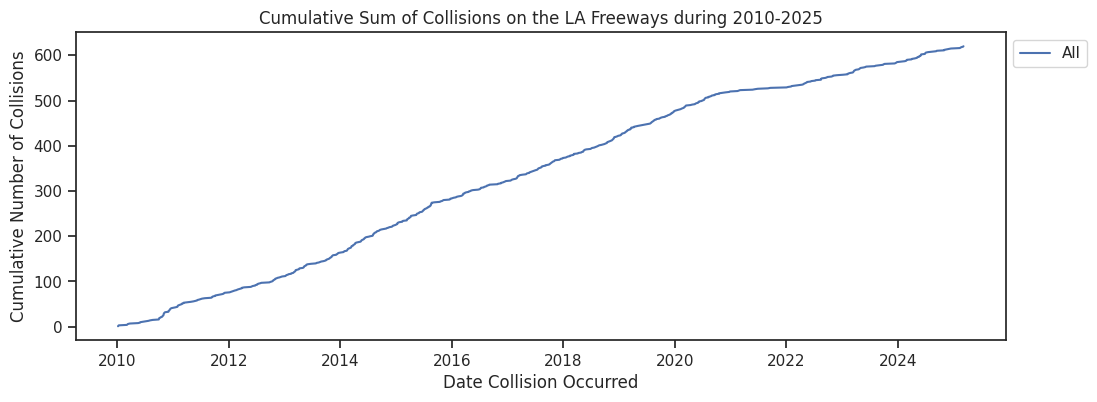

In [94]:
freeway["all"] = True

c = pd.DataFrame(freeway.groupby(freeway["dttm_occurred"].dt.date)["all"].sum())
c = c.cumsum().rename(columns={"all":"All"})
c

sns.set_theme(style="whitegrid")
sns.set_style("ticks")

fig = plt.figure(figsize=(12,4))
plt.plot(c.All, label="All")
plt.title("Cumulative Sum of Collisions on the LA Freeways during 2010-2025")
plt.xlabel("Date Collision Occurred")
plt.ylabel("Cumulative Number of Collisions")

plt.legend(bbox_to_anchor=(1,1,0,0))
plt.grid(False)

Throughout the years,  there was an increase collisions , almost linearly, except for the time period between 2020 and 2022. The plateau during that time period may be explained by the COVID precautions in LA.

In [95]:
bins = range(0,101,10)
names = ["0-10","11-20","21-30","31-40","41-50","51-60","61-70","71-80","81-90","91-98"]
freeway["age_range"] = pd.cut(freeway["victim_age"],bins,labels=names)


freeway["hour"] = freeway["dttm_occurred"].dt.hour

freeway['time_of_day'] = pd.cut(freeway["hour"],[0,4,10,16,22,24],
                             labels=['Night','Morning','Noon','Evening','Night '],
                             right=False).str.strip()

# #double-check cut is correct.
freeway[freeway["hour"].isin([0,4,10,16,22,24])][["hour","time_of_day"]].value_counts()

/tmp/ipython-input-1379009289.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  freeway["age_range"] = pd.cut(freeway["victim_age"],bins,labels=names)
/tmp/ipython-input-1379009289.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  freeway["hour"] = freeway["dttm_occurred"].dt.hour
/tmp/ipython-input-1379009289.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: htt

,,count
hour,time_of_day,
10,Noon,34
16,Evening,31
22,Night,21
4,Morning,13
0,Night,12


In [96]:
freeway["time_of_day"].value_counts()

,count
time_of_day,
Noon,213
Evening,164
Morning,152
Night,91


Most of the accidents on the freeway happens during the noon hours, this makes sense as most people are out and about during daylight hours instead of nighttime hours.

In [97]:
freeway["intersection_temp"] = freeway["address_clean"] + ", " + freeway["cross_street_clean"]
inter1 = (freeway["address_clean"] + ", " + freeway["cross_street_clean"]).tolist()
inter2 = (freeway["cross_street_clean"] + ", " + freeway["address_clean"]).tolist()

/tmp/ipython-input-426799336.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  freeway["intersection_temp"] = freeway["address_clean"] + ", " + freeway["cross_street_clean"]


In [98]:
inter_dict = {}
for i in range(len(inter1)):
    if (inter1[i] not in inter_dict.keys()) and (inter2[i] not in inter_dict.keys()):
        inter_dict[inter1[i]] = [inter1[i],inter2[i]]
    else:
        continue
inter_dict

{'HOLLYWOOD FY, VERMONT AV': ['HOLLYWOOD FY, VERMONT AV',
  'VERMONT AV, HOLLYWOOD FY'],
 'VENTURA FY, GLENDALE': ['VENTURA FY, GLENDALE', 'GLENDALE, VENTURA FY'],
 'CESAR E CHAVEZ AV, VIGNES ST': ['CESAR E CHAVEZ AV, VIGNES ST',
  'VIGNES ST, CESAR E CHAVEZ AV'],
 '110 FY, 9TH ST': ['110 FY, 9TH ST', '9TH ST, 110 FY'],
 'HOLLYWOOD FW, VERMONT AV': ['HOLLYWOOD FW, VERMONT AV',
  'VERMONT AV, HOLLYWOOD FW'],
 '5 FY, 101 FY': ['5 FY, 101 FY', '101 FY, 5 FY'],
 'RESEDA BL, VENTURA FY': ['RESEDA BL, VENTURA FY', 'VENTURA FY, RESEDA BL'],
 'HOLLYWOOD FY, GRAND AV': ['HOLLYWOOD FY, GRAND AV',
  'GRAND AV, HOLLYWOOD FY'],
 'FIGUEROA ST, 3RD ST': ['FIGUEROA ST, 3RD ST', '3RD ST, FIGUEROA ST'],
 'HARBOR FY, MARTIN LUTHER KING JR BL': ['HARBOR FY, MARTIN LUTHER KING JR BL',
  'MARTIN LUTHER KING JR BL, HARBOR FY'],
 'SATICOY ST, BELLAIRE AV': ['SATICOY ST, BELLAIRE AV',
  'BELLAIRE AV, SATICOY ST'],
 'VENTURA FY, WOODMAN AV': ['VENTURA FY, WOODMAN AV',
  'WOODMAN AV, VENTURA FY'],
 'SAN DIEGO FY

In [99]:
inter_df_temp = pd.DataFrame.from_dict(inter_dict, orient="index", columns = ["inter1", "inter2"])
inter_df = pd.melt(inter_df_temp, ignore_index=False, value_name = "intersection_temp").sort_index()
inter_df["intersection_clean"] = inter_df.index
inter_df

,variable,intersection_temp,intersection_clean
"10 FREEWAY, I5 FREEWAYY",inter2,"I5 FREEWAYY, 10 FREEWAY","10 FREEWAY, I5 FREEWAYY"
"10 FREEWAY, I5 FREEWAYY",inter1,"10 FREEWAY, I5 FREEWAYY","10 FREEWAY, I5 FREEWAYY"
"10 FWY, ARLINGTON",inter2,"ARLINGTON, 10 FWY","10 FWY, ARLINGTON"
"10 FWY, ARLINGTON",inter1,"10 FWY, ARLINGTON","10 FWY, ARLINGTON"
"10 FY, FAIRFAX AV",inter1,"10 FY, FAIRFAX AV","10 FY, FAIRFAX AV"
...,...,...,...
"YOSEMITE WY, VALLE VISTA ST",inter2,"VALLE VISTA ST, YOSEMITE WY","YOSEMITE WY, VALLE VISTA ST"
"ZOO DR, VENTURA FY",inter2,"VENTURA FY, ZOO DR","ZOO DR, VENTURA FY"
"ZOO DR, VENTURA FY",inter1,"ZOO DR, VENTURA FY","ZOO DR, VENTURA FY"
NaN,inter1,NaN,NaN


In [100]:
inter_df.drop("variable", axis=1, inplace=True)
inter_df

,intersection_temp,intersection_clean
"10 FREEWAY, I5 FREEWAYY","I5 FREEWAYY, 10 FREEWAY","10 FREEWAY, I5 FREEWAYY"
"10 FREEWAY, I5 FREEWAYY","10 FREEWAY, I5 FREEWAYY","10 FREEWAY, I5 FREEWAYY"
"10 FWY, ARLINGTON","ARLINGTON, 10 FWY","10 FWY, ARLINGTON"
"10 FWY, ARLINGTON","10 FWY, ARLINGTON","10 FWY, ARLINGTON"
"10 FY, FAIRFAX AV","10 FY, FAIRFAX AV","10 FY, FAIRFAX AV"
...,...,...
"YOSEMITE WY, VALLE VISTA ST","VALLE VISTA ST, YOSEMITE WY","YOSEMITE WY, VALLE VISTA ST"
"ZOO DR, VENTURA FY","VENTURA FY, ZOO DR","ZOO DR, VENTURA FY"
"ZOO DR, VENTURA FY","ZOO DR, VENTURA FY","ZOO DR, VENTURA FY"
NaN,NaN,NaN


In [101]:
inter_df.intersection_temp.value_counts()

,count
intersection_temp,
"INTERSTATE 1, INTERSTATE 1",2
"110 FY, 110 FY",2
"VENTURA FY, VENTURA FY",2
"STADIUM WAY, PASADENA FY",1
"STADIUM WY, PASADENA FY",1
...,...
"GOLDEN STATE FY, PASADENA FY",1
"GOLDEN STATE FY, PAXTON ST",1
"PAXTON ST, GOLDEN STATE FY",1


In [102]:
inter_df.drop_duplicates(inplace=True)
freeway = freeway.merge(inter_df,
                  on="intersection_temp")
freeway.dr_number.value_counts()

,count
dr_number,
250904176,1
190217739,1
190217672,1
200110391,1
190119707,1
...,...
190219341,1
190920860,1
191120418,1


In [103]:
freeway["intersection_clean"].value_counts()

,count
intersection_clean,
"SAN DIEGO FY, NORDHOFF ST",7
"VAN NUYS BL, VENTURA FY",7
"SAN DIEGO FY, BURBANK BL",6
"HARBOR FY, SANTA MONICA FY",6
"HOLLYWOOD FY, SHERMAN WY",6
...,...
"SEPULVEDA BL, BURBANK BL",1
"SAN FERNANDO RD, GLENDALE WY",1
"FIGUEROA ST, 3RD ST",1


In [104]:
freeway[["intersection_clean", "location"]].value_counts()

,,count
intersection_clean,location,
"SAN DIEGO FY, NORDHOFF ST","(34.2356, -118.4729)",5
"ROSCOE BL, SAN DIEGO FY","(34.2214, -118.4731)",3
"HOLLYWOOD FY, SHERMAN WY","(34.2003, -118.4002)",3
"SAN DIEGO FY, VICTORY BL","(34.1867, -118.4741)",3
"MANCHESTER AV, HARBOR FY","(33.9601, -118.2807)",2
...,...,...
"GOLDEN STATE FY, ROXFORD ST","(34.3033, -118.4798)",1
"GOLDEN STATE FY, SAN BERNARDI FY","(34.0588, -118.2221)",1
"GOLDEN STATE FY, SANTA MONICA FY","(34.0379, -118.2197)",1


In [105]:
lat = freeway["latitude"][np.logical_not(np.isnan(freeway["latitude"]))]
lon = freeway["longitude"][np.logical_not(np.isnan(freeway["longitude"]))]

top5 = freeway[["intersection_clean","latitude","longitude"]].value_counts().reset_index(name="counts").head()

map = folium.Map(location=[freeway["latitude"].mean(),freeway["longitude"].mean()],
                 zoom_start=10,
                 control_scale=True)
HeatMap(list(zip(lat, lon))).add_to(map)

for row in top5.itertuples():
    folium.Marker([row.latitude, row.longitude],
                 popup=row.intersection_clean,
                 icon=folium.Icon(color="red")).add_to(map)
map

In [106]:
top5

,intersection_clean,latitude,longitude,counts
0,"SAN DIEGO FY, NORDHOFF ST",34.2356,-118.4729,5
1,"ROSCOE BL, SAN DIEGO FY",34.2214,-118.4731,3
2,"SAN DIEGO FY, VICTORY BL",34.1867,-118.4741,3
3,"HOLLYWOOD FY, SHERMAN WY",34.2003,-118.4002,3
4,"HOLLYWOOD FY, GRAND AV",34.0615,-118.2412,2


These are the 5 most dangerous freeways in LA in terms of the number of collisions, but the danger is at most 5 collisions from Jan 2010 - March 2025, so all the freeways are about equally dangerous in LA.

## Types of Injuries

In [107]:
mo_fin['traffic'] = mo_fin["code_def"].str.contains("Traffic|^T/C|traffic", na=False)
mo_fin[mo_fin["traffic"]]["code_def"].value_counts()

,count
code_def,
T/C - PCF (A) In the Narrative,454441
T/C - Type of Collision,361373
T/C - Movement Preceding Collision,361237
T/C - Veh vs Veh,268791
T/C - At Intersection - No,252159
...,...
T/C - Train vs Bike,17
T/C - Bike vs Train,12
T/C - Traffic Control Devices,11


In [108]:
mo_fin.loc[:, "vs"] = mo_fin["code_def"].str.contains(" vs ", na=False)
mo_fin[mo_fin["vs"]]["code_def"].value_counts()

,count
code_def,
T/C - Veh vs Veh,268791
T/C - Veh vs Parked Veh,118445
T/C - Veh vs Fixed Object,38860
T/C - Veh vs Ped,36900
T/C - Veh vs Bike,19720
T/C - Veh vs M/C,8114
T/C - Veh vs Other Object,1849
T/C - Bike vs Veh,1452
T/C - M/C vs Veh,754


In [109]:
mo_fin.loc[:,"injury"] = mo_fin["code_def"].str.contains("Injury|injury", na=False)
mo_fin[mo_fin["injury"]][["mo_code","code_def"]].value_counts()

,,count
mo_code,code_def,
3028,T/C - (N) Non Injury,184098
3026,T/C - (C) Complaint of Injury,148649
3025,T/C - (B) Visible Injury,67523
3024,T/C - (A) Severe Injury,16376
3027,T/C - (K) Fatal Injury,3348


In [110]:
injuries = mo_fin[mo_fin["injury"]]
injuries["code_def"] = injuries["code_def"].str[10:]
injuries

/tmp/ipython-input-3353700139.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  injuries["code_def"] = injuries["code_def"].str[10:]


,dr_number,orig_var,mo_code,code_def,mo_code_clean,traffic,vs,injury
44,190617818,mo_code_0,3026,Complaint of Injury,3026,True,False,True
47,230118088,mo_code_0,3025,Visible Injury,3025,True,False,True
67,190618126,mo_code_0,3028,Non Injury,3028,True,False,True
108,190715905,mo_code_0,3028,Non Injury,3028,True,False,True
150,190814692,mo_code_0,3026,Complaint of Injury,3026,True,False,True
...,...,...,...,...,...,...,...,...
3522824,250104162,mo_code_9,3026,Complaint of Injury,3026,True,False,True
3522980,250704105,mo_code_9,3025,Visible Injury,3025,True,False,True
3522997,250204112,mo_code_9,3026,Complaint of Injury,3026,True,False,True
3523078,251304134,mo_code_9,3026,Complaint of Injury,3026,True,False,True


In [111]:
injuries["dr_number"].value_counts()

,count
dr_number,
201814666,3
201813339,3
200504224,3
201215962,3
240311607,3
...,...
171517708,1
171518309,1
171524265,1


In [112]:
numinjury = injuries.groupby("dr_number").agg("count").reset_index()

numinjury["injury"].value_counts()

,count
injury,
1,418198
2,883
3,10


In [113]:
injuries_freeways = injuries[injuries['dr_number'].isin(freeway['dr_number'])] #282
injuries_notfreeways = injuries[~injuries['dr_number'].isin(freeway['dr_number'])] #419712
injuries_freeways

,dr_number,orig_var,mo_code,code_def,mo_code_clean,traffic,vs,injury
63969,200317683,mo_code_0,3028,Non Injury,3028,True,False,True
72011,210310779,mo_code_0,3028,Non Injury,3028,True,False,True
88369,211609147,mo_code_0,3028,Non Injury,3028,True,False,True
137834,241009206,mo_code_0,3026,Complaint of Injury,3026,True,False,True
161462,120313632,mo_code_0,3025,Visible Injury,3025,True,False,True
...,...,...,...,...,...,...,...,...
3262125,121522064,mo_code_7,3025,Visible Injury,3025,True,False,True
3341423,161604170,mo_code_7,3024,Severe Injury,3024,True,False,True
3436638,230405930,mo_code_8,3028,Non Injury,3028,True,False,True
3443929,241309598,mo_code_8,3028,Non Injury,3028,True,False,True


In [114]:
numinjury = injuries_freeways.groupby("dr_number").agg("count").reset_index()
numinjury["injury"].value_counts()

,count
injury,
1,276
2,3


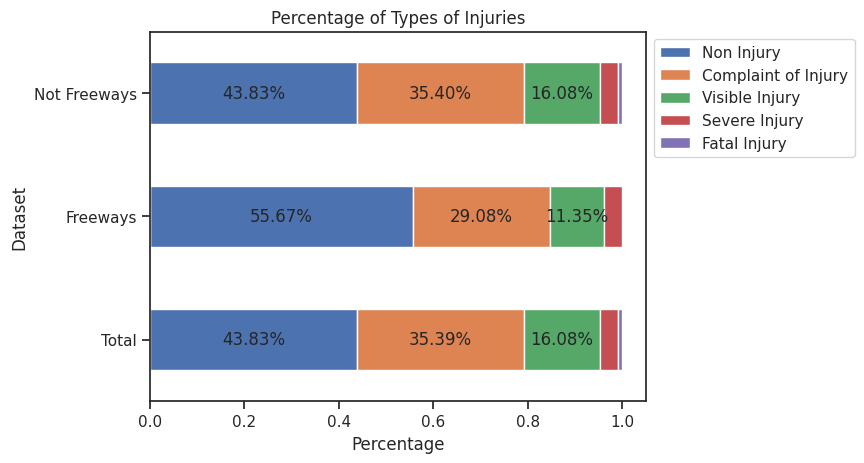

In [115]:
inj_cnt_freeways = injuries_freeways["code_def"].value_counts().sum()
inj_cnt_notfreeways = injuries_notfreeways["code_def"].value_counts().sum()


inj_total = injuries["code_def"].value_counts(normalize=True).reset_index(name="Total")
inj_freeways = injuries_freeways["code_def"].value_counts(normalize=True).reset_index(name="Freeways")
inj_notfreeways = injuries_notfreeways["code_def"].value_counts(normalize=True).reset_index(name="Not Freeways")

tot_freeways = pd.merge(inj_total,
                     inj_freeways,
                     on="code_def",
                     how="left")

tot_freeways_notfreeways = pd.merge(tot_freeways,
                          inj_notfreeways,
                           on="code_def",
                           how="left")
tot_freeways_notfreeways

inj_pct = tot_freeways_notfreeways.loc[:,["code_def","Total","Freeways","Not Freeways"]]
inj_pct
inj_pct_t = inj_pct.T
inj_pct_t.columns = inj_pct_t.iloc[0]
inj_pct_t.drop(index="code_def", inplace=True)
inj_pct_t

ax = inj_pct_t.plot(kind="barh", stacked=True)
plt.title("Percentage of Types of Injuries")
plt.xlabel("Percentage")
plt.ylabel("Dataset")
plt.legend(bbox_to_anchor=(1,1,0,0))

for bar in ax.patches:
    height = bar.get_height()
    width = bar.get_width()
    x = bar.get_x()
    y = bar.get_y()
    if width >= 0.05:
        label_text = "{:.2%}".format(width)
    else:
        label_text = ""
    label_x = x + width/2
    label_y = y + height/2
    ax.text(label_x, label_y, label_text, ha="center",va="center")

plt.show()

Interestingly enough, even though cars typically drive faster on freeways, and we would think it would be more dangerous (we see that there is at least one victim in most of the collisions on freeways), most of the injuries recorded are non-injuries and none of them are fatal. Furthermore, of the 620 freeway collisions, there are only 276 where one injury MO code was recorded and 3 where 3 where 2 injury MO codes were recorded.

In [116]:
drnums_w_injuries = mo_fin[mo_fin['injury']]['dr_number'].unique()
noinjurymocode_freeway = freeway[~freeway['dr_number'].isin(drnums_w_injuries)]

In [117]:
noinjurymocode_freeway.shape

(341, 44)

In [118]:
mo_fin[mo_fin['dr_number'].isin(noinjurymocode_freeway['dr_number'])]['code_def'].value_counts(dropna=False)

,count
code_def,
T/C - Type of Collision,83
T/C - Movement Preceding Collision,83
T/C - PCF (A) In the Narrative,78
T/C - Veh vs Veh,57
Traffic Accident/Traffic related incident,53
T/C - City Property Involved - Yes,44
T/C - Hit and Run Misd,42
T/C - Central Traffic (CTD),25
T/C - At Intersection - Yes,19


The remaining 341 records did not have an injury MO code (even though most of them have a victim associated with the collision), and there isn't enough information whether a self-driving vehicle would be safer or not.